# Post-fire debris-flow 2D modeling, built from scratch (non-Newtonian)

This notebook recreates the USACE / HEC "Expedited Debris Flow Tutorial" — a 2D HEC-RAS
debris-flow model of the Ether Hollow post-fire watershed (Utah, 2020 fire) — with
`ras-commander`, built from scratch (no starting project) as a minimal, end-to-end
demonstration, and then shows where we begin extending it. All inputs are public (USGS
post-fire debris-flow predictions, USGS 1 m lidar, an HMS design hydrograph) and are fetched
automatically.

- Recreate the tutorial — a greenfield 2D mesh + terrain, a clear-water baseline, and
  Bingham non-Newtonian variants (τy = 700 / 2500 Pa, μ = 100 Pa·s, Cv = 70 % via
  *Bulk Fluid Volume* bulking), inflow at the basin outlet / fan apex.
- Begin extending it — the Full-Momentum solver, TauDEM channel breaklines, depth×velocity
  hazard mapping, a parameter-sensitivity band, and a volume-matched scenario bracket.

> Units note. The model is US-Customary (feet); horizontal + vertical terrain are in feet.
> Non-Newtonian rheology is always entered in SI (Pa, Pa·s) — HEC-RAS does not convert it.
>
> Environment. The build/run steps drive HEC-RAS (RAS Mapper / `Ras.exe`) and must run on
> Windows in an interactive desktop session. Paths below are placeholders.

## Source & attribution

This example recreates the U.S. Army Corps of Engineers / Hydrologic Engineering Center (HEC)
"Expedited Debris Flow Tutorial" (HEC-RAS *Guides & Tutorials → Mud and Debris Flow*),
which models this same Ether Hollow (Utah, 2020 fire) watershed with the Bingham
non-Newtonian method. We keep the tutorial's case study, rheology (Bingham; `τy = 700 /
2500 Pa`, `μ = 100 Pa·s`), *Bulk Fluid Volume* bulking at `Cv = 70 %`, and outlet /
fan-apex inflow, and rebuild the workflow programmatically with `ras-commander`. HEC's
documentation notes the key convention used below — volumetric concentration is entered in
percent — so the bulking factor is `1/(1−Cv) = 3.33` at `Cv = 0.70`.

- Tutorial — [Expedited Debris Flow Tutorial](https://www.hec.usace.army.mil/confluence/rasdocs/hgt/latest/tutorials/mud-and-debris-flow/expedited-debris-flow-tutorial)
- Non-Newtonian User's Manual — [Bulking Options](https://www.hec.usace.army.mil/confluence/rasdocs/rasmuddebris/non-newtonian-user-s-manual/user-inputs-and-model-parameters/bulking-options) / [Concentration](https://www.hec.usace.army.mil/confluence/rasdocs/rasmuddebris/non-newtonian-user-s-manual/user-inputs-and-model-parameters/concentration)

## 0. Setup

In [1]:
# --- environment + configuration -------------------------------------------------
from pathlib import Path
from types import SimpleNamespace
import ras_commander

ROOT = Path(".")                          # run from examples/post_fire_debris_flow
WORKDIR = ROOT / "ether_hollow_proj"      # HEC-RAS project workspace (gitignored)
DATA = ROOT / "data" / "ether_hollow"     # fetched public inputs (gitignored)
PREP = DATA / "prep"

M_PER_USFT = 1200.0 / 3937.0              # exact US survey foot
M_TO_USFT = 1.0 / M_PER_USFT

# All model knobs in one place (tutorial-faithful choices):
cfg = SimpleNamespace(
    project_name="EtherHollow", cell_size_ft=33.0, mannings_n=0.08,
    inflow_at="outlet",                                   # basin outlet / fan apex
    inflow_width_ft=200.0, outflow_width_ft=300.0, buffer_ft=300.0,
    runout_m=1600.0, corridor_width_m=200.0, no_corridor=False,
    dem_source="py3dep", py3dep_res=1, dem_tif=None, dem_projects="",  # gap-free 3DEP
    yields="700,2500", cv=0.70, viscosity_pa=100.0,      # Bingham rheology
    equation_set="DWE", sim_hours=6.0, comp_interval="1SEC",  # diffusion wave, 6 h
    inflow_scale=1.0, breaklines=False,
    channel_width_ft=30.0, channel_cell_ft=12.0, breakline_simplify_ft=10.0,
    root=ROOT, workdir=WORKDIR, data_dir=None, status=ROOT / "ether_hollow_status.jsonl",
)
print("ras_commander", getattr(ras_commander, "__version__", "(imported)"))


ras_commander 0.93.0


In [2]:
# --- utility functions (data prep + result extraction) ---------------------------
# Pure-Python helpers reused by the section cells below. The ras_commander HEC-RAS API
# itself is shown inline in sections 2-4, not hidden here.
import io, json, math, shutil, urllib.request, zipfile
from pathlib import Path

M_PER_USFT = 1200.0 / 3937.0
M_TO_USFT = 1.0 / M_PER_USFT

_BASE = "https://www.hec.usace.army.mil"
_BURN_ZIP = _BASE + "/confluence/rasdocs/hgt/files/latest/139727587/349474539/1/1774897218397/Ether-Hollow_2020-09-07_eth2020.zip"
_PROJ_PRJ = _BASE + "/confluence/rasdocs/hgt/files/latest/139727587/349474546/1/1774897428985/DebrisProjection_USCust.prj"
_HMS_XLSX = _BASE + "/confluence/rasdocs/hgt/files/latest/139727587/167249013/1/1699048223644/HMS+Hydrograph+SI.xlsx"
_HEADERS = {"User-Agent": "ras-commander-example/1.0 (ether-hollow tutorial inputs)"}


def _get(url):
    with urllib.request.urlopen(urllib.request.Request(url, headers=_HEADERS), timeout=180) as r:
        return r.read()


def banner(m):
    print("\n" + "=" * 78 + f"\n{m}\n" + "=" * 78)


def status(rec):
    from datetime import datetime
    rec = {"ts": datetime.now().isoformat(timespec="seconds"), **rec}
    with open(cfg.status, "a", encoding="utf-8") as f:
        f.write(json.dumps(rec) + "\n")
    print("[status]", rec)


def _get(url: str) -> bytes:
    req = urllib.request.Request(url, headers=_HEADERS)
    with urllib.request.urlopen(req, timeout=180) as r:  # noqa: S310 (fixed HTTPS host)
        return r.read()

def fetch(root: Path = Path("."), *, dem: bool = False, force: bool = False) -> Path:
    """Download the tutorial inputs into ``<root>/data/ether_hollow/``. Idempotent:
    existing files are skipped unless ``force``. Returns the data directory."""
    data = Path(root) / "data" / "ether_hollow"
    burn = data / "burn"
    burn.mkdir(parents=True, exist_ok=True)

    # 1. USGS post-fire DF-prediction shapefiles (basin hazard/volume + basin points).
    #    Extract the eth2020_* members flat into burn/ (matches select_basin()'s paths).
    marker = burn / "eth2020_Basin_DFPredictions_15min_12mmh.shp"
    if force or not marker.exists():
        with zipfile.ZipFile(io.BytesIO(_get(_BURN_ZIP))) as z:
            members = [m for m in z.namelist() if Path(m).name.startswith("eth2020_")]
            for m in members:
                (burn / Path(m).name).write_bytes(z.read(m))
        print(f"[fetch] burn shapefiles ({len(members)} files) -> {burn}")
    else:
        print(f"[fetch] burn shapefiles present ({marker.name})")

    # 2. US-Customary (feet UTM 12N) model projection.
    prj = data / "DebrisProjection_USCust.prj"
    if force or not prj.exists():
        prj.write_bytes(_get(_PROJ_PRJ))
        print(f"[fetch] {prj.name}")

    # 3. HMS design hydrograph — saved under the underscore name the data phase reads
    #    (the download's own name uses spaces).
    xlsx = data / "HMS_Hydrograph_SI.xlsx"
    if force or not xlsx.exists():
        xlsx.write_bytes(_get(_HMS_XLSX))
        print(f"[fetch] {xlsx.name}")

    # 4. Optional: the tutorial's reference 1 m DEM tile. The data phase normally mosaics
    #    3DEP on demand; this gives a fixed, offline-reproducible terrain if you prefer it.
    if dem:
        tdir = data / "tutorial_dem"
        tdir.mkdir(exist_ok=True)
        tif = tdir / "USGS_one_meter_x45y445_UT_Wasatch_L5_2014.tif"
        if force or not tif.exists():
            tif.write_bytes(_get(_DEM_TIF))
            print(f"[fetch] {tif.name}")

    print(f"[fetch] inputs ready under {data}")
    return data

def banner(m):
    print("\n" + "=" * 78 + f"\n{m}\n" + "=" * 78)

def select_basin(data_dir: Path, intensity: str = "12mmh"):
    """Pick the highest combined-hazard basin from the USGS DF predictions.

    intensity "12mmh" matches the HEC tutorial's design storm
    (eth2020_Basin_DFPredictions_15min_12mmh).
    """
    import geopandas as gpd
    shp = data_dir / "burn" / f"eth2020_Basin_DFPredictions_15min_{intensity}.shp"
    gdf = gpd.read_file(shp)
    # rank by combined hazard then debris-flow volume
    gdf = gdf.sort_values(["CombHaz", "Volume"], ascending=False).reset_index(drop=True)
    row = gdf.iloc[0]
    info = {
        "basin_id": int(row.get("BASIN_ID", -1)),
        "segment_id": int(row.get("Segment_ID", -1)) if "Segment_ID" in gdf.columns else -1,
        "up_area_km2": float(row["UpArea_km2"]),
        "volume_m3": float(row["Volume"]),
        "vol_min_m3": float(row["VolMin"]),
        "vol_max_m3": float(row["VolMax"]),
        "prob": float(row["P"]),
        "comb_haz": int(row.get("CombHaz", -1)),
        "comb_haz_class": str(row.get("CombHazCl_", "")),
        "src_crs": str(gdf.crs),
    }
    return gdf.iloc[[0]], info

def runout_corridor(dem_path: Path, outlet_xy, src_crs,
                    max_dist_m: float = 1600.0, step_m: float = 10.0,
                    width_m: float = 120.0):
    """Trace a steepest-descent flow path from the basin outlet on the DEM and
    return a buffered corridor polygon (in the DEM's CRS).

    Captures the downstream runout/deposition reach (the tutorial extends the 2D
    area ~1 mile downstream onto the alluvial fan). Coarse stepping + a simple
    pit-escape keeps the trace robust on a 1 m DEM.
    """
    import numpy as np
    import rasterio
    from shapely.geometry import LineString

    with rasterio.open(dem_path) as ds:
        arr = ds.read(1).astype("float64")
        nodata = ds.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        tf = ds.transform
        H, W = arr.shape
        dem_crs = ds.crs

        def elev(x, y):
            c, r = ~tf * (x, y)
            r, c = int(round(r)), int(round(c))
            if 0 <= r < H and 0 <= c < W:
                return arr[r, c]
            return np.nan

        # outlet_xy is in src_crs; index it in the DEM grid CRS (no-op when
        # 3DEP serves the basin CRS, correct if it ever differs).
        ox, oy = float(outlet_xy[0]), float(outlet_xy[1])
        if src_crs is not None and dem_crs is not None and str(dem_crs) != str(src_crs):
            from pyproj import Transformer
            ox, oy = Transformer.from_crs(src_crs, dem_crs, always_xy=True).transform(ox, oy)
        x, y = ox, oy
        pts = [(x, y)]
        dirs = [(step_m * math.cos(a), step_m * math.sin(a))
                for a in [i * math.pi / 4 for i in range(8)]]
        last = None
        dist = 0.0
        while dist < max_dist_m:
            here = elev(x, y)
            here = here if np.isfinite(here) else np.inf
            best, bd = None, None
            # search increasing radii to step over small pits/flats
            for mult in (1.0, 2.0, 3.0):
                bz = here
                for dx, dy in dirs:
                    z = elev(x + dx * mult, y + dy * mult)
                    if np.isfinite(z) and z < bz:
                        bz, best, bd = z, (x + dx * mult, y + dy * mult), (dx, dy)
                if best is not None:
                    break
            if best is None:           # true pit -> coast in last direction, else stop
                if last is None:
                    break
                cand = (x + last[0], y + last[1])
                if not np.isfinite(elev(*cand)):
                    break
                best, bd = cand, last
            px, py = x, y
            x, y = best
            last = bd
            pts.append((x, y))
            dist += math.hypot(x - px, y - py)   # true step length (handles
            #                  pit-escape 2x/3x jumps and diagonal x sqrt(2))
        if len(pts) < 2:
            return None
        corridor = LineString(pts).buffer(width_m / 2.0, cap_style=2)
        # the trace runs in the DEM grid's CRS; return it in the caller's
        # src_crs so the downstream union stays single-CRS even if 3DEP ever
        # serves a projection other than the basin's.
        if src_crs is not None and dem_crs is not None and str(dem_crs) != str(src_crs):
            import geopandas as gpd
            corridor = gpd.GeoSeries([corridor], crs=dem_crs).to_crs(src_crs).iloc[0]
        return corridor

def fetch_3dep_mosaic(area_gdf, out_dir: Path, projects) -> Path:
    """Download USGS 3DEP 1 m tiles from one or more projects covering
    ``area_gdf`` and merge them into one GeoTIFF.

    A basin that straddles 3DEP project boundaries is not fully covered by any
    single tile/project (each has nodata gores at its project edge), so we
    mosaic MULTIPLE projects. ``projects`` is listed newest-first; merge uses
    method='first', so earlier (newer) sources win and later ones fill nodata.
    """
    import rasterio
    from rasterio.merge import merge
    from ras_commander.terrain.Usgs3depAws import Usgs3depAws

    out_dir.mkdir(parents=True, exist_ok=True)
    mosaic_path = out_dir / "dem_3dep_mosaic.tif"
    if mosaic_path.exists():
        print(f"[data] 3DEP mosaic cached: {mosaic_path}")
        return mosaic_path
    bbox = tuple(float(v) for v in area_gdf.to_crs(4326).total_bounds)
    print(f"[data] 3DEP fetch bbox(wgs84)={[round(v,4) for v in bbox]} projects={projects}")
    all_tiles = []
    for proj in projects:
        proj = str(proj).strip()
        if not proj:
            continue
        try:
            tiles = Usgs3depAws.download_tiles(bbox, 1, out_dir, project_name=proj)
        except Exception as e:  # noqa: BLE001
            print(f"[data]   project {proj}: fetch failed ({e})")
            tiles = []
        if not tiles:  # already-present tiles may be skipped by download_tiles
            tiles = sorted(out_dir.glob(f"*{proj}*.tif"))
        print(f"[data]   project {proj}: {len(tiles)} tile(s)")
        all_tiles.extend(tiles)
    if not all_tiles:
        # 3DEP project names drift (USGS re-publishes/renames collections), so a
        # hard-coded list eventually finds nothing. Auto-discover whatever 1 m projects
        # currently cover the bbox and mosaic them newest-first — drift-proof.
        print("[data]   named projects yielded no tiles — auto-discovering 3DEP coverage")
        try:
            avail = Usgs3depAws.list_projects_for_bbox(bbox, 1, out_dir)
        except Exception as e:  # noqa: BLE001
            avail = None
            print(f"[data]   project discovery failed ({e})")
        if avail is not None and len(avail):
            namecol = next((c for c in ("proj_name", "project", "demname")
                            if c in avail.columns), None)
            disc = avail.sort_values("_year", ascending=False) if "_year" in avail.columns else avail
            names = [str(n) for n in (disc[namecol].tolist() if namecol else [])
                     if str(n) and str(n).lower() != "nan"]
            print(f"[data]   discovered projects (newest first): {names}")
            for proj in names:
                try:
                    tiles = Usgs3depAws.download_tiles(bbox, 1, out_dir, project_name=proj)
                except Exception as e:  # noqa: BLE001
                    print(f"[data]   project {proj}: fetch failed ({e})")
                    tiles = []
                if not tiles:
                    tiles = sorted(out_dir.glob(f"*{proj}*.tif"))
                print(f"[data]   project {proj}: {len(tiles)} tile(s)")
                all_tiles.extend(tiles)
    if not all_tiles:  # last resort: let download_tiles pick all intersecting tiles
        try:
            all_tiles = list(Usgs3depAws.download_tiles(bbox, 1, out_dir) or [])
        except Exception as e:  # noqa: BLE001
            print(f"[data]   unfiltered 3DEP download failed ({e})")
    if not all_tiles:
        raise RuntimeError(f"No 3DEP 1m tiles found for bbox {bbox} "
                           f"(named={projects}, discovery exhausted)")
    srcs = [rasterio.open(t) for t in all_tiles]
    try:
        arr, tf = merge(srcs, method="first")   # newest-first ordering wins
        meta = srcs[0].meta.copy()
        meta.update(driver="GTiff", height=arr.shape[1], width=arr.shape[2],
                    transform=tf, count=1, compress="deflate")
        with rasterio.open(mosaic_path, "w", **meta) as dst:
            dst.write(arr[0], 1)
    finally:
        for s in srcs:
            s.close()
    print(f"[data] 3DEP mosaic: {mosaic_path} from {len(all_tiles)} tile(s) / "
          f"{len(projects)} project(s)")
    return mosaic_path

def fetch_py3dep_dem(area_gdf, out_path: Path, resolution_m=1) -> Path:
    """Gap-free terrain over ``area_gdf`` from the USGS 3DEP **dynamic** service (py3dep),
    written as a GeoTIFF in the area's CRS. Unlike the static S3 tile path
    (``fetch_3dep_mosaic``), this mosaics all available 1 m sources on the fly, so it is
    immune to project-name drift and single-tile nodata gores. Needs ``py3dep``."""
    import py3dep
    import rioxarray  # noqa: F401  (registers the .rio accessor)
    out_path = Path(out_path)
    if out_path.exists():
        print(f"[data] py3dep DEM cached: {out_path}")
        return out_path
    out_path.parent.mkdir(parents=True, exist_ok=True)
    geom_wgs = area_gdf.to_crs(4326).geometry.iloc[0]
    print(f"[data] py3dep get_dem res={resolution_m} m over {round(area_gdf.geometry.iloc[0].area/1e6,2)} km2 ...")
    dem = py3dep.get_dem(geom_wgs, resolution=resolution_m, crs=4326)     # xarray, EPSG:5070
    dem = dem.rio.reproject(area_gdf.crs.to_wkt())                        # -> area CRS (m)
    dem.rio.to_raster(out_path)
    print(f"[data] py3dep DEM -> {out_path}")
    return out_path

def clip_to_valid_terrain(domain_geom, dem_path, cell_m):
    """Intersect ``domain_geom`` with the DEM's valid-data footprint (largest connected
    non-nodata region, eroded ~1 cell), so the 2D flow area sits entirely on real
    elevations. This is what restricts the domain to the fan/runout reach the HEC tutorial
    tile actually covers — a mesh over nodata makes HEC-RAS reject the terrain ("does not
    completely cover the 2D Flow Area"). No-op if the DEM already covers the domain."""
    import numpy as np
    import rasterio
    from rasterio.mask import mask as rio_mask
    from rasterio.features import shapes as rio_shapes
    from shapely.geometry import shape, box
    from shapely.ops import unary_union
    with rasterio.open(dem_path) as src:
        nd = src.nodata
        arr, tf = rio_mask(src, [box(*domain_geom.bounds).__geo_interface__], crop=True,
                           filled=True, nodata=nd if nd is not None else -9999.0)
    a = arr[0]
    ndv = nd if nd is not None else -9999.0
    valid = np.isfinite(a) & (a != ndv)
    if valid.mean() >= 0.999:
        return domain_geom, 1.0
    polys = [shape(g) for g, v in rio_shapes(valid.astype("uint8"), mask=valid, transform=tf)
             if v == 1]
    if not polys:
        return domain_geom, 0.0
    # The raw valid footprint is a 1 m pixel staircase (vertices far below the cell size) —
    # a "dirty" perimeter that makes the RAS mesher emit zero cells. Simplify, then
    # morphologically close+open to drop islands/slivers into one smooth blob, then erode
    # ~1 cell so mesh edge faces stay off the nodata boundary.
    footprint = (unary_union(polys).buffer(0).simplify(cell_m * 0.5)
                 .buffer(cell_m).buffer(-2.0 * cell_m).buffer(cell_m)   # close then open
                 .buffer(-cell_m))
    if footprint.geom_type == "MultiPolygon":
        footprint = max(footprint.geoms, key=lambda g: g.area)
    footprint = footprint.simplify(cell_m * 0.5).buffer(0)
    clipped = domain_geom.intersection(footprint)
    if clipped.is_empty:
        return domain_geom, 0.0
    if clipped.geom_type == "MultiPolygon":
        clipped = max(clipped.geoms, key=lambda g: g.area)
    return clipped, clipped.area / domain_geom.area

def _sample_terrain_elev(dem_path, pts):
    """Sample the feet terrain (same CRS as the ring) at each (x,y); NaN off-grid."""
    import rasterio
    import numpy as np
    with rasterio.open(dem_path) as ds:
        arr = ds.read(1).astype("float64")
        nd = ds.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        tf = ds.transform
        H, W = arr.shape
        out = []
        for x, y in pts:
            c, r = ~tf * (float(x), float(y))
            r, c = int(round(r)), int(round(c))
            out.append(float(arr[r, c]) if 0 <= r < H and 0 <= c < W else float("nan"))
    return out

def _pick_bc_segment(ring, elevs, mode, span_ft):
    """Contiguous run of perimeter vertices centred on the highest ('high') or
    lowest ('low') elevation vertex, grown until it spans ~span_ft. Returns the
    ordered [x,y] polyline for a BC line that lies on the domain edge."""
    import numpy as np
    pts = ring[:-1] if ring and list(ring[0]) == list(ring[-1]) else list(ring)
    n = len(pts)
    e = np.asarray(elevs[:n], dtype=float)
    c = 0 if np.all(np.isnan(e)) else int(
        np.nanargmax(e) if mode == "high" else np.nanargmin(e))

    def seglen(idxs):
        return sum(math.hypot(pts[idxs[i + 1]][0] - pts[idxs[i]][0],
                              pts[idxs[i + 1]][1] - pts[idxs[i]][1])
                   for i in range(len(idxs) - 1))

    k = 1
    while True:
        idxs = [(c + j) % n for j in range(-k, k + 1)]
        if seglen(idxs) >= span_ft or (2 * k + 1) >= n:
            break
        k += 1
    return [[float(pts[(c + j) % n][0]), float(pts[(c + j) % n][1])]
            for j in range(-k, k + 1)]

def _pick_bc_segment_near(ring, pt, span_ft):
    """Contiguous perimeter run centred on the vertex nearest point ``pt`` (e.g.
    the basin outlet / fan apex), grown until it spans ~span_ft."""
    pts = ring[:-1] if ring and list(ring[0]) == list(ring[-1]) else list(ring)
    n = len(pts)
    c = min(range(n), key=lambda i: (pts[i][0] - pt[0]) ** 2 + (pts[i][1] - pt[1]) ** 2)

    def seglen(idxs):
        return sum(math.hypot(pts[idxs[i + 1]][0] - pts[idxs[i]][0],
                              pts[idxs[i + 1]][1] - pts[idxs[i]][1])
                   for i in range(len(idxs) - 1))

    k = 1
    while True:
        idxs = [(c + j) % n for j in range(-k, k + 1)]
        if seglen(idxs) >= span_ft or (2 * k + 1) >= n:
            break
        k += 1
    return [[float(pts[(c + j) % n][0]), float(pts[(c + j) % n][1])]
            for j in range(-k, k + 1)]

def _bed_slope(dem_path, outflow_pts, centroid_xy, probe_ft=400.0,
               lo=0.002, hi=0.5, default=0.02):
    """Local bed slope just above the outflow line (Δelev over probe_ft toward
    the domain centroid) — the EG slope for the downstream normal-depth BC."""
    mx = sum(p[0] for p in outflow_pts) / len(outflow_pts)
    my = sum(p[1] for p in outflow_pts) / len(outflow_pts)
    dx, dy = centroid_xy[0] - mx, centroid_xy[1] - my
    d = math.hypot(dx, dy) or 1.0
    up = (mx + dx / d * probe_ft, my + dy / d * probe_ft)
    e_out, e_up = _sample_terrain_elev(dem_path, [(mx, my), up])
    if not (math.isfinite(e_out) and math.isfinite(e_up)):
        return default
    return float(min(hi, max(lo, (e_up - e_out) / probe_ft)))

def _nn_block(nn):
    """Full HEC-RAS Non-Newtonian block for the .u## (templated from a real
    fixture, exact keys incl. the HEC-RAS misspelling 'User Yeild'). nn keys:
    method (1=Bingham), cv, user_yield (Pa), user_viscosity (Pa*s),
    bulking (1=Bulk Fluid Volume), max_cv."""
    # HEC-RAS stores volumetric concentration in PERCENT (70 = 70%), not a
    # fraction. nn['cv'] is kept as a fraction (0.70) for the bulking-factor math;
    # write it ×100 here. (Writing 0.70 makes HEC-RAS read 0.7% -> bulking 1.007×.)
    cv_pct = nn["cv"] * 100.0
    maxcv_pct = nn.get("max_cv", 0.75) * 100.0
    return [
        f"Non-Newtonian Method= {nn['method']} ,",
        f"Non-Newtonian Constant Vol Conc={cv_pct:g}",
        "Non-Newtonian Yield Method= 1 ,",          # User Yield
        "Non-Newtonian Yield Coef=0, 0",
        f"User Yeild=   {nn['user_yield']}",          # sic: HEC-RAS key is misspelled
        "Non-Newtonian Sed Visc= 2 ,",               # User Defined Viscosity
        "Non-Newtonian Obrian B=0",
        f"User Viscosity={nn['user_viscosity']}",
        "User Viscosity Ratio=0",
        "Herschel-Bulkley Coef=0, 0",
        "Clastic Method= 0 ,",
        "Coulomb Phi=0",
        "Non-Newtonian Hindered FV= 0",
        "Non-Newtonian FV K=0",
        "Non-Newtonian ds=0",
        f"Non-Newtonian Max Cv={maxcv_pct:g}",
        f"Non-Newtonian Bulking Method= {nn['bulking']} ,",
        "Non-Newtonian High C Transport= 0 ,",
        "Viscosity=1000,,,",
    ]

def write_unsteady_2d(path, area, inflow_name, hydro_cfs, interval,
                      outflow_name, friction_slope, title="Clear Water", nn=None):
    """Hand-author a greenfield 2D unsteady flow file (.u##): one Flow Hydrograph
    inflow BC + one Normal Depth outflow BC. ras-commander has no Boundary
    Location= block creator, so emit the HEC-RAS text directly. The 2D Boundary
    Location format is 9 comma fields: field 6 = 2D area, field 8 = BC line."""
    def loc(bcname):
        f = [f"{'':<16}", f"{'':<16}", f"{'':<8}", f"{'':<8}", f"{'':<16}",
             f"{area:<16}", f"{'':<16}", f"{bcname:<32}", f"{'':<32}"]
        return "Boundary Location=" + ",".join(f)

    L = [f"Flow Title={title}", "Program Version=7.00",
         "BEGIN FILE DESCRIPTION:", "END FILE DESCRIPTION:", "Use Restart= 0 "]
    L.append(loc(inflow_name))
    L.append(f"Interval={interval}")
    L.append(f"Flow Hydrograph= {len(hydro_cfs)} ")
    for i in range(0, len(hydro_cfs), 10):
        L.append("".join(f"{float(v):8.2f}" for v in hydro_cfs[i:i + 10]))
    L += ["Stage Hydrograph TW Check=0", "Flow Hydrograph Slope= 0 ",
          "DSS Path=", "Use DSS=False", "Use Fixed Start Time=False",
          "Fixed Start Date/Time=,", "Is Critical Boundary=False",
          "Critical Boundary Flow="]
    L.append(loc(outflow_name))
    L.append(f"Friction Slope={friction_slope:.5f},0")
    if nn:
        L += _nn_block(nn)   # global rheology block (mud/debris flow)
    Path(path).write_text("\n".join(L) + "\n", encoding="utf-8")

def _inflow_volume(plan_hdf, area):
    """Realized inflow (peak cfs, volume m3) from the BC flow-per-face time series
    — a mass-balance QA: bulked NN runs should show ~1/(1-Cv)x the clear volume."""
    import h5py
    import numpy as np
    tsb = ("Results/Unsteady/Output/Output Blocks/Base Output/"
           f"Unsteady Time Series/2D Flow Areas/{area}/Boundary Conditions")
    try:
        with h5py.File(plan_hdf, "r") as f:
            fpf = f.get(f"{tsb}/Inflow - Flow per Face")
            if fpf is None:
                return None
            tot = np.abs(np.asarray(fpf[:], float)).sum(axis=1)
            vol = float(np.sum((tot[:-1] + tot[1:]) / 2.0) * 60.0) * 0.0283168  # 1-min->m3
            return {"inflow_peak_cfs": round(float(tot.max()), 1),
                    "inflow_vol_m3": round(vol)}
    except Exception as e:  # noqa: BLE001
        print(f"[run] WARNING: inflow-volume read failed: {e}")
        return None

def _results_summary(plan_hdf, geom_hdf, area):
    """Max WSE / depth / velocity for the 2D area from the plan HDF. Returns None
    if the run produced no 2D results (failed or went unstable)."""
    import h5py
    import numpy as np
    if not Path(plan_hdf).exists():
        print(f"[run] WARNING: plan HDF missing: {plan_hdf}")
        return None
    try:
        with h5py.File(plan_hdf, "r") as f:
            base = ("Results/Unsteady/Output/Output Blocks/Base Output/"
                    f"Summary Output/2D Flow Areas/{area}")
            grp = f.get(base)
            if grp is None:
                print(f"[run] WARNING: no 2D summary results at {base}")
                parent = f.get("Results/Unsteady/Output/Output Blocks/"
                               "Base Output/Summary Output/2D Flow Areas")
                if parent is not None:
                    print("[run] available 2D area result groups:", list(parent.keys()))
                return None

            def maxrow(ds):
                a = grp.get(ds)
                if a is None:
                    return None
                a = a[:]
                return a[0] if a.ndim == 2 else a   # (2,N) = [value, time]

            out = {}
            ws = maxrow("Maximum Water Surface")
            if ws is not None:
                wf = ws[np.isfinite(ws)]
                if wf.size:
                    out["max_ws_ft"] = round(float(wf.max()), 2)
                with h5py.File(geom_hdf, "r") as g:
                    el = g.get(f"Geometry/2D Flow Areas/{area}/Cells Minimum Elevation")
                    if el is not None:
                        el = el[:]
                        n = min(len(ws), len(el))
                        depth = ws[:n] - el[:n]
                        depth = depth[np.isfinite(depth) & (depth > 0.0)]
                        if depth.size:
                            out["max_depth_ft"] = round(float(depth.max()), 2)
                            out["mean_depth_ft"] = round(float(depth.mean()), 2)
                            out["wet_cells"] = int(depth.size)
            vel = maxrow("Maximum Face Velocity")
            if vel is None:
                vel = maxrow("Maximum Velocity")
            if vel is not None:
                vf = vel[np.isfinite(vel)]
                if vf.size:
                    out["max_vel_fps"] = round(float(vf.max()), 2)
            return out or None
    except Exception as e:
        print(f"[run] WARNING: results read failed: {e}")
        return None

def _mesh_elevation_summary(geom_hdf: Path, area: str):
    """Return {min,max,mean} of 'Cells Minimum Elevation' (ft) or None if absent."""
    import h5py
    import numpy as np
    if not geom_hdf.exists():
        return None
    try:
        with h5py.File(geom_hdf, "r") as f:
            d = f.get(f"Geometry/2D Flow Areas/{area}/Cells Minimum Elevation")
            if d is None:
                return None
            a = d[:]
            a = a[np.isfinite(a)]
            if a.size == 0:
                return None
            return {"min": round(float(a.min()), 1), "max": round(float(a.max()), 1),
                    "mean": round(float(a.mean()), 1), "n": int(a.size)}
    except Exception as e:
        # distinguish a genuine read failure from "dataset absent" (which
        # returns None above) so a locked/partial HDF isn't misread as
        # "terrain not in mesh" and silently fails the build.
        print(f"[build] WARNING: Cells Minimum Elevation read failed: {e}")
        return None

def hdf_has_2d_mesh(geom_hdf: Path):
    """Return (ok, detail): a 2D Flow Areas group with cells exists."""
    import h5py
    if not geom_hdf.exists():
        return False, f"{geom_hdf.name} missing"
    try:
        with h5py.File(geom_hdf, "r") as f:
            grp = f.get("Geometry/2D Flow Areas")
            if grp is None:
                return False, "no '2D Flow Areas' group"
            areas = [k for k in grp.keys() if isinstance(grp[k], h5py.Group)]
            if not areas:
                return False, "no area subgroups"
            tot = 0
            det = []
            for a in areas:
                cc = grp.get(f"{a}/Cells Center Coordinate")
                n = 0 if cc is None else cc.shape[0]
                tot += n
                det.append(f"{a}:{n} cells")
            return tot > 0, "; ".join(det)
    except Exception as e:
        return False, f"HDF read error: {e}"


## 1. Data — basin selection, 3DEP mosaic, reproject to feet

> Inputs — reproducible from scratch. Every input is public data published with the
> HEC tutorial: the burn-area debris-flow-prediction shapefiles, the US-Customary
> projection, and the HMS design hydrograph. The companion `fetch_inputs.py` downloads them
> (and `--phase data` auto-fetches if they're missing); 3DEP lidar is pulled on demand — so
> the pipeline runs with nothing pre-staged:
> ```bash
> python fetch_inputs.py --root .                                          # burn shp + projection + HMS hydrograph
> python ether_hollow_debris_flow.py --phase data  --root .                # basin → 3DEP mosaic → feet terrain
> python ether_hollow_debris_flow.py --phase build --root . --workdir ether_hollow_proj   # HEC-RAS (interactive)
> python ether_hollow_debris_flow.py --phase run   --root . --workdir ether_hollow_proj   # HEC-RAS (interactive)
> ```

The USGS post-fire assessment ships per-basin debris-flow combined-hazard class and
volume. We pick the highest-hazard basin, then fetch 3DEP 1 m lidar. The basin
straddles two 3DEP projects, so a single tile leaves a NODATA gore over the outlet —
we mosaic *both* projects (newest first, fill the gaps from the older one).

The 2D domain is the source basin unioned with a downstream runout corridor (a
steepest-descent trace from the outlet, buffered). The union is healed with
`make_valid` + `buffer(0)`, simplified below the cell size, and oriented CCW — a dirty
buffered-polyline perimeter otherwise makes the mesher emit zero cells. Finally the
domain + terrain are reprojected to the feet CRS and elevations converted m → US ft.

In [3]:
# === Section 1 data: fetch public inputs, select basin, gap-free 3DEP DEM, runout
# corridor, clip to valid terrain, reproject to feet, read the HMS hydrograph. ===
args = cfg
data_dir = DATA
prep = PREP
prep.mkdir(parents=True, exist_ok=True)
if not (DATA / 'burn' / 'eth2020_Basin_DFPredictions_15min_12mmh.shp').exists():
    fetch(ROOT)

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask as rio_mask

# feet CRS from HEC's projection file
feet_wkt = (data_dir / "DebrisProjection_USCust.prj").read_text(encoding="utf-8")
from pyproj import CRS
feet_crs = CRS.from_wkt(feet_wkt)
print("[data] feet CRS:", feet_crs.name)

from shapely.ops import unary_union

basin_gdf, info = select_basin(data_dir)
print("[data] selected basin:", json.dumps(info, indent=2))
src_crs_data = basin_gdf.crs  # EPSG:26912 (m)

# Terrain source. Default = the HEC tutorial's own 1 m DEM tile (most faithful to
# the tutorial, and a single 10 km tile that fully covers this basin + runout
# corridor). '--dem-source 3dep' instead mosaics live USGS 3DEP (subject to the
# project-name drift handled in fetch_3dep_mosaic); '--dem-tif' overrides with an
# explicit GeoTIFF.
cover = gpd.GeoDataFrame(
    geometry=[basin_gdf.geometry.iloc[0].buffer(args.runout_m + 500.0)],
    crs=src_crs_data)
if args.dem_tif:
    dem_src = Path(args.dem_tif)
    if not dem_src.exists():
        raise FileNotFoundError(f"--dem-tif not found: {dem_src}")
    print(f"[data] terrain: explicit DEM {dem_src}")
elif args.dem_source == "py3dep":
    dem_src = fetch_py3dep_dem(cover, data_dir / "3dep" / "py3dep_dem.tif",
                               resolution_m=args.py3dep_res)
    print(f"[data] terrain: py3dep 3DEP dynamic ({args.py3dep_res} m)")
elif args.dem_source == "tutorial":
    _fetch_inputs = fetch
    _fetch_inputs(args.root, dem=True)   # ensure the tutorial tile is present
    cands = sorted((data_dir / "tutorial_dem").glob("*.tif"))
    if not cands:
        raise FileNotFoundError("tutorial DEM tile missing after fetch")
    dem_src = cands[0]
    print(f"[data] terrain: HEC tutorial DEM {dem_src.name}")
else:  # "3dep"
    dem_src = fetch_3dep_mosaic(cover, data_dir / "3dep",
                                projects=args.dem_projects.split(","))

# outlet point for this basin (pour point), else basin representative point
pts = gpd.read_file(data_dir / "burn" / "eth2020_basinpt_feat.shp")
sel = pts[pts["BASIN_ID"] == info["basin_id"]] if "BASIN_ID" in pts.columns else pts.iloc[0:0]
if len(sel):
    outlet_xy = (float(sel.geometry.iloc[0].x), float(sel.geometry.iloc[0].y))
else:
    rp = basin_gdf.geometry.iloc[0].representative_point()
    outlet_xy = (rp.x, rp.y)
print("[data] outlet(m):", [round(v, 1) for v in outlet_xy])

# downstream runout corridor + union with the source basin -> 2D domain
if args.no_corridor:
    corridor = None
    print("[data] basin-only domain (--no-corridor): runout trace skipped")
else:
    corridor = runout_corridor(dem_src, outlet_xy, src_crs_data,
                               max_dist_m=args.runout_m, step_m=10.0,
                               width_m=args.corridor_width_m)
from shapely import make_valid
from shapely.geometry import MultiPolygon
from shapely.geometry.polygon import orient

geoms = [basin_gdf.geometry.iloc[0]]
if corridor is not None and not corridor.is_empty:
    geoms.append(corridor)
else:
    print("[data] WARNING: runout corridor trace degenerate; "
          "domain = source basin only")
# A buffered flow-line union has slivers / self-intersections / vertices
# spaced below the cell size — RAS Mapper's PointGenerator then yields no
# computation points and the mesher emits ZERO cells. Heal the union and
# drop sub-cell vertices before it becomes the 2D-area perimeter.
cell_m = args.cell_size_ft * M_PER_USFT
domain_src = make_valid(unary_union(geoms)).buffer(0)
if isinstance(domain_src, MultiPolygon):
    parts = sorted(domain_src.geoms, key=lambda g: g.area, reverse=True)
    print(f"[data] domain union split into {len(parts)} parts "
          f"(basin/corridor disjoint?); keeping largest "
          f"({parts[0].area/1e6:.3f} km2)")
    domain_src = parts[0]
domain_src = domain_src.simplify(cell_m * 0.5).buffer(0)
print(f"[data] domain (basin+corridor): {domain_src.area/1e6:.3f} km2, "
      f"{len(domain_src.exterior.coords)} verts")
# Restrict the 2D area to where the DEM actually has data (the fan/runout reach the
# HEC tutorial models). The single tutorial tile only has valid lidar over the
# outlet + downstream fan, so without this the mesh lands on nodata and HEC-RAS
# rejects the terrain. No-op when the DEM fully covers the domain (e.g. 3DEP mosaic).
domain_src, frac = clip_to_valid_terrain(domain_src, dem_src, cell_m)
domain_src = make_valid(domain_src).buffer(0).simplify(cell_m * 0.5).buffer(0)
if isinstance(domain_src, MultiPolygon):
    domain_src = max(domain_src.geoms, key=lambda g: g.area)
print(f"[data] domain clipped to valid terrain: {domain_src.area/1e6:.3f} km2 "
      f"({frac*100:.0f}% of basin+corridor), {len(domain_src.exterior.coords)} verts")
domain_gdf = gpd.GeoDataFrame(geometry=[domain_src], crs=src_crs_data)

# reproject domain -> feet, enforce CCW exterior orientation, write perimeter
domain_ft = domain_gdf.to_crs(feet_crs)
poly_ft = orient(domain_ft.geometry.iloc[0], sign=1.0)
domain_ft = gpd.GeoDataFrame(geometry=[poly_ft], crs=feet_crs)
domain_ft.to_file(prep / "domain_ft.shp")
ring = list(poly_ft.exterior.coords)
(prep / "basin_perimeter_ft.json").write_text(
    json.dumps([[float(x), float(y)] for x, y in ring]), encoding="utf-8")
minx, miny, maxx, maxy = domain_ft.total_bounds
print(f"[data] domain perimeter: {len(ring)} verts, bounds(ft)="
      f"{[round(v,1) for v in (minx,miny,maxx,maxy)]}")

# Build the feet terrain on an EXPLICIT grid covering the domain (buffered), then
# reproject the DEM into it. (The previous calculate_default_transform sizing left a
# dst canvas WIDER than the reprojected data — ~half the mesh landed on nodata and
# HEC-RAS rejected the terrain: "does not completely cover the 2D Flow Area". An
# explicit grid over poly_ft guarantees the whole mesh sits on valid elevations.)
from shapely.geometry import box as _box
NODATA = -9999.0   # numeric sentinel (RAS terrains dislike NaN nodata)
dom_buf = domain_gdf.buffer(args.buffer_ft * M_PER_USFT)
with rasterio.open(dem_src) as src:
    nd = src.nodata
    src_res_m = abs(src.transform.a)
    bbox = _box(*dom_buf.to_crs(src.crs).total_bounds)
    clip, clip_tf = rio_mask(src, [bbox.__geo_interface__], crop=True,
                             filled=True, nodata=nd if nd is not None else NODATA)
    src_crs = src.crs
clip = clip[0].astype("float32")
if nd is not None:
    clip[clip == nd] = np.nan
# explicit feet grid over the (buffered) domain, at ~the source DEM resolution
res_ft = max(src_res_m / M_PER_USFT, 1.0)          # ~3.28 ft for a 1 m DEM
minx, miny, maxx, maxy = gpd.GeoSeries([poly_ft], crs=feet_crs).buffer(
    args.buffer_ft).total_bounds
w = int(np.ceil((maxx - minx) / res_ft))
h = int(np.ceil((maxy - miny) / res_ft))
dst_tf = rasterio.transform.from_origin(minx, maxy, res_ft, res_ft)
dst = np.full((h, w), np.nan, dtype="float32")
reproject(source=clip, destination=dst,
          src_transform=clip_tf, src_crs=src_crs,
          dst_transform=dst_tf, dst_crs=feet_crs,
          src_nodata=np.nan, dst_nodata=np.nan,
          resampling=Resampling.bilinear)
# vertical m -> US ft, then write with a numeric nodata sentinel
dst = dst * M_TO_USFT
dem_ft = prep / "EtherHollow_terrain_ft.tif"
dst_out = np.where(np.isfinite(dst), dst, NODATA).astype("float32")
with rasterio.open(dem_ft, "w", driver="GTiff", height=h, width=w, count=1,
                   dtype="float32", crs=feet_crs, transform=dst_tf,
                   nodata=NODATA, compress="deflate") as out:
    out.write(dst_out, 1)
# also write the ESRI .prj sidecar
(dem_ft.with_suffix(".prj")).write_text(feet_crs.to_wkt("WKT1_ESRI"), encoding="utf-8")
nfin = int(np.isfinite(dst).sum())
print(f"[data] feet terrain: {dem_ft} ({w}x{h}, finite={nfin}, "
      f"elev {np.nanmin(dst):.0f}-{np.nanmax(dst):.0f} ft, nodata={NODATA})")

# clear-water inflow hydrograph (US Customary CFS, 1-min ordinates) from
# the HMS export — NOT pre-bulked (bulking is the Bulk Fluid Volume option
# in the non-Newtonian phase). Written to prep/ for staging to the runner.
import pandas as pd
hg = pd.read_excel(data_dir / "HMS_Hydrograph_SI.xlsx",
                   sheet_name="US Cust", header=None)
cfs = [round(float(v), 2) for v in
       pd.to_numeric(hg.iloc[:, 2], errors="coerce").dropna().to_numpy()]
(prep / "inflow_hydrograph.json").write_text(
    json.dumps({"interval": "1MIN", "units": "cfs", "cfs": cfs}),
    encoding="utf-8")
print(f"[data] inflow hydrograph: {len(cfs)} ords @1MIN, "
      f"peak {max(cfs):.0f} cfs at min {cfs.index(max(cfs))+1}")

# basin outlet / fan apex in feet CRS (for the --inflow-at outlet placement)
from shapely.geometry import Point as _Point
outlet_ft = gpd.GeoSeries([_Point(*outlet_xy)], crs=src_crs_data).to_crs(feet_crs).iloc[0]
(prep / "outlet_ft.json").write_text(
    json.dumps([float(outlet_ft.x), float(outlet_ft.y)]), encoding="utf-8")
# copy the model-CRS projection into prep so the build phase can read it
# from the default prep dir (when --data-dir is not passed explicitly).
import shutil as _shutil
_shutil.copy2(data_dir / "DebrisProjection_USCust.prj",
              prep / "DebrisProjection_USCust.prj")

status({"phase": "data", "ok": True, "basin": info,
        "perimeter_verts": len(ring), "hydrograph_ords": len(cfs),
        "peak_cfs": max(cfs),
        "dem_ft": str(dem_ft), "dem_shape": [int(h), int(w)]})


[data] feet CRS: NAD83 / UTM zone 12N
[data] selected basin: {
  "basin_id": 165,
  "segment_id": 165,
  "up_area_km2": 0.9865,
  "volume_m3": 9019.1536929,
  "vol_min_m3": 1126.76478471,
  "vol_max_m3": 72193.5353681,
  "prob": 0.285545725618,
  "comb_haz": 4,
  "comb_haz_class": "Moderate",
  "src_crs": "EPSG:26912"
}


[data] py3dep DEM cached: data\ether_hollow\3dep\py3dep_dem.tif
[data] terrain: py3dep 3DEP dynamic (1 m)
[data] outlet(m): [452906.7, 4443905.4]


2026-07-04 18:59:41 - pyogrio._io - INFO - Created 1 records


[data] domain (basin+corridor): 1.169 km2, 308 verts
[data] domain clipped to valid terrain: 1.169 km2 (100% of basin+corridor), 308 verts
[data] domain perimeter: 308 verts, bounds(ft)=[np.float64(1484505.6), np.float64(14577892.2), np.float64(1492899.6), np.float64(14580779.4)]


[data] feet terrain: data\ether_hollow\prep\EtherHollow_terrain_ft.tif (3139x1217, finite=3820163, elev 4787-7536 ft, nodata=-9999.0)
[data] inflow hydrograph: 481 ords @1MIN, peak 328 cfs at min 21
[status] {'ts': '2026-07-04T18:59:42', 'phase': 'data', 'ok': True, 'basin': {'basin_id': 165, 'segment_id': 165, 'up_area_km2': 0.9865, 'volume_m3': 9019.1536929, 'vol_min_m3': 1126.76478471, 'vol_max_m3': 72193.5353681, 'prob': 0.285545725618, 'comb_haz': 4, 'comb_haz_class': 'Moderate', 'src_crs': 'EPSG:26912'}, 'perimeter_verts': 308, 'hydrograph_ords': 481, 'peak_cfs': 328.35, 'dem_ft': 'data\\ether_hollow\\prep\\EtherHollow_terrain_ft.tif', 'dem_shape': [1217, 3139]}


## 2. Greenfield 2D build

This is the heart of the example: a runnable 2D mesh from a blank template. The
sequence is order-sensitive:

1. `create_project_from_template` — a bundled blank 7.0 project, reprojected to our feet CRS.
2. `set_2d_flow_area_perimeter` — author the 2D flow area from the domain ring.
3. `set_2d_flow_area_settings(mannings_n=…)` — base roughness (text edit, not an HDF write).
4. `generate_computation_points` — RAS Mapper point generator → seed points in the `.g01` text.
5. `GeomBcLines.add_bc_lines` — inflow line at the basin outlet / fan apex,
   normal-depth outflow on the lowest (fan toe).
6. `create_terrain_from_rasters` + `add_terrain_layer` — the feet DEM as a RAS terrain.
7. `compute_plan(force_geompre=True)` — HEC-RAS preprocessor builds the mesh topology.
8. `set_geometry_association` + `compute_property_tables` — put terrain elevations into
   the mesh (the step that makes `Cells Minimum Elevation` populate).

In [4]:
# === Section 2 greenfield build (drives HEC-RAS): the ras_commander API sequence —
# create_project_from_template -> 2D area + roughness -> computation points -> outlet
# inflow / normal-depth outflow -> terrain -> mesh -> terrain-in-mesh property tables. ===
args = cfg
data_dir = DATA
prep = PREP

from ras_commander import init_ras_project, create_project_from_template, RasCmdr
from ras_commander.terrain.RasTerrain import RasTerrain
from ras_commander.RasMap import RasMap
from ras_commander.geom.GeomStorage import GeomStorage
from ras_commander.geom.GeomMesh import GeomMesh
from ras_commander.geom.GeomBcLines import GeomBcLines

ddir = args.data_dir or (prep)
feet_wkt = (ddir / "DebrisProjection_USCust.prj").read_text(encoding="utf-8")
ring = json.loads((ddir / "basin_perimeter_ft.json").read_text(encoding="utf-8"))
dem_ft = ddir / "EtherHollow_terrain_ft.tif"
cell = int(args.cell_size_ft)
name = args.project_name
wd = args.workdir
wd.parent.mkdir(parents=True, exist_ok=True)

# 1. instantiate project from template (feet UTM 12N CRS)
prj = create_project_from_template(
    wd, project_name=name, version="7.0", target_crs=feet_wkt, overwrite=True)
init_ras_project(str(wd), "7.0")
geom_text = wd / f"{name}.g01"
rasmap = wd / f"{name}.rasmap"
proj_prj = wd / f"{name}.projection.prj"
print(f"[build] instantiated {prj.name}")

# 2. author the 2D flow-area perimeter + initial computation points
GeomStorage.set_2d_flow_area_perimeter(
    geom_file=geom_text, flow_area_name="DebrisFlowArea",
    coordinates=ring, point_generation_data=[None, None, cell, cell])
# realistic base roughness for post-fire steep terrain (template default
# 0.04 is too smooth -> over-fast velocities). Set in geometry text; HEC-RAS
# applies it to cells during preprocessing (not a direct cell-n HDF write).
GeomStorage.set_2d_flow_area_settings(
    geom_file=geom_text, flow_area_name="DebrisFlowArea",
    mannings_n=args.mannings_n)
print(f"[build] base Manning's n = {args.mannings_n}")
gp = GeomMesh.generate_computation_points(
    str(geom_text), mesh_name="DebrisFlowArea", cell_size=float(cell))
print(f"[build] generate_computation_points -> status={getattr(gp,'status',None)} "
      f"pts={getattr(gp,'cell_count',None)}")

# 2b. author inflow + outflow BC lines on the domain edge. The inflow line
#     sits on the highest-elevation perimeter segment (basin head, where the
#     runoff hydrograph enters), the normal-depth outflow on the lowest
#     (corridor/fan toe). Sample the feet terrain at each ring vertex to
#     locate them; friction slope = local bed slope above the outflow.
elevs = _sample_terrain_elev(dem_ft, ring)
outflow_pts = _pick_bc_segment(ring, elevs, "low", args.outflow_width_ft)
outlet_json = ddir / "outlet_ft.json"
if args.inflow_at == "outlet" and outlet_json.exists():
    outlet_pt = json.loads(outlet_json.read_text(encoding="utf-8"))
    inflow_pts = _pick_bc_segment_near(ring, outlet_pt, args.inflow_width_ft)
    print(f"[build] inflow at OUTLET/apex near {[round(v) for v in outlet_pt]}")
else:
    inflow_pts = _pick_bc_segment(ring, elevs, "high", args.inflow_width_ft)
    print("[build] inflow at basin HEAD (highest-elevation perimeter)")
cx = sum(p[0] for p in ring) / len(ring)
cy = sum(p[1] for p in ring) / len(ring)
fslope = _bed_slope(dem_ft, outflow_pts, (cx, cy))
GeomBcLines.add_bc_lines(geom_text, replace_existing=True, lines=[
    {"name": "Inflow", "storage_area": "DebrisFlowArea", "coordinates": inflow_pts},
    {"name": "Outflow", "storage_area": "DebrisFlowArea", "coordinates": outflow_pts},
])
(wd / "bc_meta.json").write_text(json.dumps({
    "inflow_name": "Inflow", "outflow_name": "Outflow",
    "friction_slope": round(fslope, 5), "inflow_at": args.inflow_at,
    "inflow_verts": len(inflow_pts), "outflow_verts": len(outflow_pts),
}), encoding="utf-8")
print(f"[build] BC lines: Inflow({len(inflow_pts)} pts) + "
      f"Outflow({len(outflow_pts)} pts), friction_slope={fslope:.4f}")

# 3. create the RAS terrain from the feet DEM + register it in the .rasmap
terrain_hdf = RasTerrain.create_terrain_from_rasters(
    input_rasters=[dem_ft], output_folder=wd / "Terrain",
    terrain_name="Terrain", units="Feet", hecras_version="7.0")
print(f"[build] terrain: {terrain_hdf}")
RasMap.add_terrain_layer(terrain_hdf, rasmap, layer_name="Terrain",
                         projection_prj=proj_prj)

# 4. minimal geometry-only flow + plan; register in .prj
(wd / f"{name}.u01").write_text(
    "Flow Title=Geometry Only\nProgram Version=7.00\n"
    "BEGIN FILE DESCRIPTION:\nEND FILE DESCRIPTION:\nUse Restart= 0 \n",
    encoding="utf-8")
# geometry-preprocessor-only bootstrap (Run UNet=0): build mesh + 2D tables
# without running the solver, so the newly-added BC lines (which have no
# flow data yet) don't trigger an unsteady "boundary not specified" error.
(wd / f"{name}.p01").write_text(
    "Plan Title=Mesh Bootstrap\nProgram Version=7.00\n"
    "Geom File=g01\nFlow File=u01\nRun HTab=-1\nRun UNet= 0\nRun Sed= 0\n"
    "Run WQ= 0\nShort ID=MESHBOOT\n"
    "Simulation Date=01JAN2000,0000,01JAN2000,0100\n"
    "Computation Interval=30SEC\nOutput Interval=1HOUR\n"
    "Instantaneous Interval=15MIN\nMapping Interval=1HOUR\n", encoding="utf-8")
txt = prj.read_text(encoding="utf-8", errors="replace")
if "Current Plan=" not in txt:
    lines, out = txt.splitlines(keepends=True), []
    for ln in lines:
        out.append(ln)
        if ln.startswith("Proj Title="):
            out.append("Current Plan=p01\n")
    txt = "".join(out)
if ("Plan File=p01" not in txt or "Unsteady File=u01" not in txt) \
        and "Geom File=g01\n" not in txt:
    raise RuntimeError(
        "template .prj has no 'Geom File=g01' anchor line; cannot "
        "register plan/flow files via text insertion")
if "Plan File=p01" not in txt:
    txt = txt.replace("Geom File=g01\n", "Geom File=g01\nPlan File=p01\n", 1)
if "Unsteady File=u01" not in txt:
    txt = txt.replace("Geom File=g01\n", "Geom File=g01\nUnsteady File=u01\n", 1)
prj.write_text(txt, encoding="utf-8")

# 5. build the mesh TOPOLOGY (HEC-RAS geometry preprocessor); force_geompre
#    rebuilds the .g01.hdf from the .g01 text + 2D points.
geom_hdf = wd / f"{name}.g01.hdf"
init_ras_project(str(wd), "7.0")
cres = RasCmdr.compute_plan("01", force_geompre=True, num_cores=2)
topo_ok, topo_detail = hdf_has_2d_mesh(geom_hdf)
print(f"[build] mesh topology: {topo_ok} ({topo_detail})")

# 5b. (optional) channel-centerline breaklines from the TauDEM delineation:
#     align mesh faces to the thalweg and refine a constant-width corridor.
#     near=far (uniform fine spacing, no coarsening within the corridor);
#     near_repeats sized so the refined band ~= the channel width.
bl_json = ddir / "channel_breakline_ft.json"
if args.breaklines and bl_json.exists():
    from shapely.geometry import LineString
    bl_defs = json.loads(bl_json.read_text(encoding="utf-8"))
    near = far = float(args.channel_cell_ft)
    near_repeats = max(1, round(args.channel_width_ft / (2.0 * near)))
    GeomStorage.set_breaklines(geom_text, "DebrisFlowArea", [
        {"name": d["name"][:32],
         "coords": list(LineString(d["coords"]).simplify(
             args.breakline_simplify_ft, preserve_topology=True).coords),
         "cell_size_near": near, "cell_size_far": far}
        for d in bl_defs])
    GeomMesh.set_breakline_spacing(str(geom_text), near=near, far=far,
                                   near_repeats=near_repeats, protection_radius=1,
                                   all_breaklines=True)
    print(f"[build] breaklines: {len(bl_defs)} centerline(s), near=far={near} ft, "
          f"near_repeats={near_repeats}, protection_radius=1")
    # breakline-aware mesh regeneration (.NET EnforceBreaklines + the 8-tier
    # auto-repair of bad faces); recompile_via_rasexe rebuilds the stale HDF.
    mres = GeomMesh.generate(str(geom_text), mesh_name="DebrisFlowArea",
                             cell_size=float(cell), bl_spacing_near=near,
                             bl_spacing_far=far, near_repeats=near_repeats,
                             max_iterations=8, recompile_via_rasexe=True)
    print(f"[build] breakline regen -> status={getattr(mres,'status',None)} "
          f"pts={getattr(mres,'cell_count',None)}")
    # rebuild the mesh HDF from the new breakline-aware computation points
    cres = RasCmdr.compute_plan("01", force_geompre=True, num_cores=2)
    topo_ok, topo_detail = hdf_has_2d_mesh(geom_hdf)
    print(f"[build] mesh topology (breakline): {topo_ok} ({topo_detail})")

# 6. associate terrain to the COMPILED geometry HDF, then compute the 2D
#    property tables (Cells Minimum Elevation, face profiles, ...). This
#    is what actually puts terrain elevations INTO the mesh — it must run
#    AFTER the topology HDF exists (the prior bug deleted the HDF after a
#    pre-compute association, so terrain never reached the mesh).
GeomMesh.set_geometry_association("01", terrain_hdf_path=str(terrain_hdf))
pt_ok = GeomMesh.compute_property_tables("01", mesh_name="DebrisFlowArea")
print(f"[build] compute_property_tables -> {pt_ok}")

# 7. verify terrain elevations are now in the mesh
elev = _mesh_elevation_summary(geom_hdf, "DebrisFlowArea")
ok = elev is not None
status({"phase": "build", "ok": ok, "topology": topo_detail,
        "property_tables": bool(pt_ok), "elevation_ft": elev,
        "gen_status": getattr(gp, "status", None),
        "terrain_hdf": str(terrain_hdf), "compute_result": str(cres)[:150]})
print(f"[build] terrain elevations in mesh: {elev}")


2026-07-04 18:59:42 - ras_commander.RasPrj - INFO - Created project 'EtherHollow' from RAS 7.0 template in ether_hollow_proj (reprojected to PROJCS["NAD_1983_UTM_Zone_12N",GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["false_easting",1640416.666666667],PARAMETER["false_northing",0.0],PARAMETER["central_meridian",-111.0],PARAMETER["scale_factor",0.9996],PARAMETER["latitude_of_origin",0.0],UNIT["Foot_US",0.3048006096012192]])


2026-07-04 18:59:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-07-04 18:59:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-07-04 18:59:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe via filesystem (x86)


2026-07-04 18:59:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


...

[build] mesh topology: True (DebrisFlowArea:10690 cells)


2026-07-04 18:59:57 - ras_commander.geom.GeomMesh - INFO - Updated geometry associations on EtherHollow.g01.hdf: terrain_hdf_path


2026-07-04 18:59:57 - ras_commander.RasPlan - INFO - Found geometry path: ether_hollow_proj\EtherHollow.g01


2026-07-04 19:00:02 - ras_commander.geom.GeomMesh - INFO - Property tables computed for 'DebrisFlowArea' in EtherHollow.g01


[build] compute_property_tables -> True
[status] {'ts': '2026-07-04T19:00:02', 'phase': 'build', 'ok': True, 'topology': 'DebrisFlowArea:10690 cells', 'property_tables': True, 'elevation_ft': {'min': 4815.4, 'max': 7453.0, 'mean': 5892.1, 'n': 10230}, 'gen_status': 'success', 'terrain_hdf': 'ether_hollow_proj\\Terrain\\Terrain.hdf', 'compute_result': 'ComputeResult(SUCCESS, results_df_row=available)'}
[build] terrain elevations in mesh: {'min': 4815.4, 'max': 7453.0, 'mean': 5892.1, 'n': 10230}


## 3. Clear-water baseline

The inflow is the HMS clear-water hydrograph (peak ≈ 328 cfs), placed on the `Inflow` BC line
at the basin outlet / fan apex (the tutorial's placement); the downstream BC is Normal
Depth at the local bed slope. The baseline uses HEC-RAS's default Diffusion Wave solver at
a fixed 1 s computation interval. Clear-water peak velocity is ≈ 9 fps on the steep fan.

## 4. Bingham non-Newtonian variants

Debris flow is modeled as a Bingham fluid: a yield stress `τy` must be exceeded before
motion, plus a plastic viscosity `μ`. The clear-water inflow is bulked internally by
HEC-RAS via Bulk Fluid Volume at volumetric concentration `Cv` — do *not* pre-bulk the
hydrograph. At `Cv = 0.70` the bulking factor is `1/(1−Cv) = 3.33` (peak ≈ 1094 cfs of
mixture).

`RasUnsteady` exposes the non-Newtonian setters (`set_non_newtonian_method` /
`_concentration` / `_shear`); they edit an existing block, so the `.u01` must already carry
a Non-Newtonian block (initialize from a template or the GUI). Rheology is in Pa / Pa·s.

> ⚠️ Units gotcha. HEC-RAS stores volumetric concentration in percent — pass
> `cv=70.0` for 70 %, *not* `0.70`. Writing the fraction yields `Cv = 0.7 %` and a bulking
> factor of only 1.007×. Always verify the realized inflow volume (below): bulked flow
> should be `1/(1−Cv)` times the clear-water inflow.

In [5]:
# === Sections 3-4 run (drives HEC-RAS): clear-water baseline + Bingham tau_y 700/2500;
# the clear-water hydrograph is bulked internally via Bulk Fluid Volume at Cv=70%. ===
args = cfg
data_dir = DATA
prep = PREP

from ras_commander import init_ras_project, RasCmdr
import shutil

name = args.project_name
wd = args.workdir
geom_hdf = wd / f"{name}.g01.hdf"
plan_hdf = wd / f"{name}.p01.hdf"
ddir = args.data_dir or prep
hyd = json.loads((ddir / "inflow_hydrograph.json").read_text(encoding="utf-8"))
bcm = json.loads((wd / "bc_meta.json").read_text(encoding="utf-8"))
cfs, interval = hyd["cfs"], hyd["interval"]
if args.inflow_scale != 1.0:
    cfs = [round(c * args.inflow_scale, 2) for c in cfs]
    print(f"[run] inflow scaled x{args.inflow_scale} (peak {max(cfs):.0f} cfs)")

# clear-water baseline + one Bingham variant per yield stress. The inflow
# hydrograph stays clear-water; HEC-RAS bulks it internally via Bulk Fluid
# Volume at Cv (do NOT pre-bulk). BF = 1/(1-Cv); Cv=0.70 -> 3.33x.
yields = [float(y) for y in str(args.yields).split(",") if y.strip()]
variants = [("clear", None)] + [
    (f"bingham_ty{int(y)}", {
        "method": 1, "cv": args.cv, "user_yield": y,
        "user_viscosity": args.viscosity_pa, "bulking": 1,
        "max_cv": max(round(args.cv + 0.05, 2), 0.75)})
    for y in yields]

hh = int(args.sim_hours)
mm = int(round((args.sim_hours - hh) * 60))
end = f"01JAN2000,{hh:02d}{mm:02d}"
bf = 1.0 / (1.0 - args.cv)
print(f"[run] inflow peak {max(cfs):.0f} cfs (clear); bulked peak "
      f"{max(cfs) * bf:.0f} cfs at Cv={args.cv} (BF={bf:.2f}); "
      f"sim {args.sim_hours} h @{args.comp_interval}; variants={[v[0] for v in variants]}")

init_ras_project(str(wd), "7.0")
allres = {}
for vname, nn in variants:
    # Run HTab=-1: HEC-RAS runs its native geometry preprocessor as part of
    # the run (the unsteady engine reads its own geometry tables; HTab=0
    # fails "re-run the preprocessor"). NN rheology rides in the .u01.
    write_unsteady_2d(
        wd / f"{name}.u01", area="DebrisFlowArea",
        inflow_name=bcm["inflow_name"], hydro_cfs=cfs, interval=interval,
        outflow_name=bcm["outflow_name"], friction_slope=bcm["friction_slope"],
        title=f"Ether Hollow {vname}", nn=nn)
    (wd / f"{name}.p01").write_text(
        f"Plan Title={vname}\nProgram Version=7.00\n"
        "Geom File=g01\nFlow File=u01\nRun HTab=-1\nRun UNet=-1\nRun Sed= 0\n"
        f"Run WQ= 0\nRun PostProcess=-1\nRun RASMapper= 0\nShort ID={vname[:24]}\n"
        f"Simulation Date=01JAN2000,0000,{end}\n"
        f"Computation Interval={args.comp_interval}\nOutput Interval=1MIN\n"
        "Instantaneous Interval=1MIN\nMapping Interval=1MIN\n"
        # 2D equation set: 1 = SWE-ELM (Full Momentum), required for
        # non-Newtonian debris flow; 0 = Diffusion Wave (not applicable).
        f"UNET D2 Equation= {1 if args.equation_set == 'SWE-ELM' else 0} \n",
        encoding="utf-8")
    print(f"\n[run] === variant {vname} (nn={nn}) ===")
    cres = RasCmdr.compute_plan("01", num_cores=2)
    res = _results_summary(plan_hdf, geom_hdf, "DebrisFlowArea")
    inflow = _inflow_volume(plan_hdf, "DebrisFlowArea")
    if res is not None and inflow is not None:
        res = {**res, **inflow}
    try:                                   # persist each variant's plan HDF
        if plan_hdf.exists():
            shutil.copy2(plan_hdf, wd / f"result_{vname}.p01.hdf")
    except Exception as e:                 # noqa: BLE001
        print(f"[run] WARNING: could not persist {vname} HDF: {e}")
    allres[vname] = res
    status({"phase": "run", "variant": vname, "nn": nn,
            "mannings_n": args.mannings_n, "cell_size_ft": args.cell_size_ft,
            "inflow_at": bcm.get("inflow_at", args.inflow_at),
            "ok": bool(cres) and res is not None, "results": res,
            "sim_hours": args.sim_hours, "comp_interval": args.comp_interval,
            "compute_result": str(cres)[:120]})
    print(f"[run] {vname}: {res}")

print("\n=== variant comparison (max over domain) ===")
print(f"  {'variant':18s} {'inflowQ':>8} {'maxV(fps)':>9} {'maxD(ft)':>9} "
      f"{'meanD(ft)':>9} {'wet':>6}")
for vname, res in allres.items():
    if res:
        print(f"  {vname:18s} {res.get('inflow_peak_cfs','-'):>8} "
              f"{res.get('max_vel_fps','-'):>9} "
              f"{res.get('max_depth_ft','-'):>9} {res.get('mean_depth_ft','-'):>9} "
              f"{res.get('wet_cells','-'):>6}")


2026-07-04 19:00:02 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-07-04 19:00:02 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-07-04 19:00:02 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe via filesystem (x86)


2026-07-04 19:00:02 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-07-04 19:00:02 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


...

[status] {'ts': '2026-07-04T19:04:43', 'phase': 'run', 'variant': 'bingham_ty700', 'nn': {'method': 1, 'cv': 0.7, 'user_yield': 700.0, 'user_viscosity': 100.0, 'bulking': 1, 'max_cv': 0.75}, 'mannings_n': 0.08, 'cell_size_ft': 33.0, 'inflow_at': 'outlet', 'ok': True, 'results': {'max_ws_ft': 7453.01, 'max_depth_ft': 12.57, 'mean_depth_ft': 3.26, 'wet_cells': 834, 'max_vel_fps': 7.01, 'inflow_peak_cfs': 1094.5, 'inflow_vol_m3': 44749}, 'sim_hours': 6.0, 'comp_interval': '1SEC', 'compute_result': 'ComputeResult(SUCCESS, results_df_row=available)'}
[run] bingham_ty700: {'max_ws_ft': 7453.01, 'max_depth_ft': 12.57, 'mean_depth_ft': 3.26, 'wet_cells': 834, 'max_vel_fps': 7.01, 'inflow_peak_cfs': 1094.5, 'inflow_vol_m3': 44749}

[run] === variant bingham_ty2500 (nn={'method': 1, 'cv': 0.7, 'user_yield': 2500.0, 'user_viscosity': 100.0, 'bulking': 1, 'max_cv': 0.75}) ===


2026-07-04 19:05:55 - ras_commander.RasCmdr - INFO - HEC-RAS execution completed for plan: 01


2026-07-04 19:05:55 - ras_commander.RasCmdr - INFO - Total run time for plan 01: 71.91 seconds


2026-07-04 19:05:55 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog stopped — no dialogs encountered


[status] {'ts': '2026-07-04T19:05:55', 'phase': 'run', 'variant': 'bingham_ty2500', 'nn': {'method': 1, 'cv': 0.7, 'user_yield': 2500.0, 'user_viscosity': 100.0, 'bulking': 1, 'max_cv': 0.75}, 'mannings_n': 0.08, 'cell_size_ft': 33.0, 'inflow_at': 'outlet', 'ok': True, 'results': {'max_ws_ft': 7453.01, 'max_depth_ft': 18.83, 'mean_depth_ft': 4.5, 'wet_cells': 542, 'max_vel_fps': 5.17, 'inflow_peak_cfs': 1094.5, 'inflow_vol_m3': 44749}, 'sim_hours': 6.0, 'comp_interval': '1SEC', 'compute_result': 'ComputeResult(SUCCESS, results_df_row=available)'}
[run] bingham_ty2500: {'max_ws_ft': 7453.01, 'max_depth_ft': 18.83, 'mean_depth_ft': 4.5, 'wet_cells': 542, 'max_vel_fps': 5.17, 'inflow_peak_cfs': 1094.5, 'inflow_vol_m3': 44749}

=== variant comparison (max over domain) ===
  variant             inflowQ maxV(fps)  maxD(ft) meanD(ft)    wet
  clear                 328.4      9.06      8.82      1.48    925
  bingham_ty700        1094.5      7.01     12.57      3.26    834
  bingham_ty2500    

                       inflow (cfs)  max V (fps)  max D (ft)  mean D (ft)  wet cells  inflow vol (m3)
variant                                                                                              
Clear water                   328.4         9.06        8.82         1.48        925            13425
Bingham  τy = 700 Pa         1094.5         7.01       12.57         3.26        834            44749
Bingham  τy = 2500 Pa        1094.5         5.17       18.83         4.50        542            44749

bulking: 3.33x  (1/(1-Cv) = 3.33)


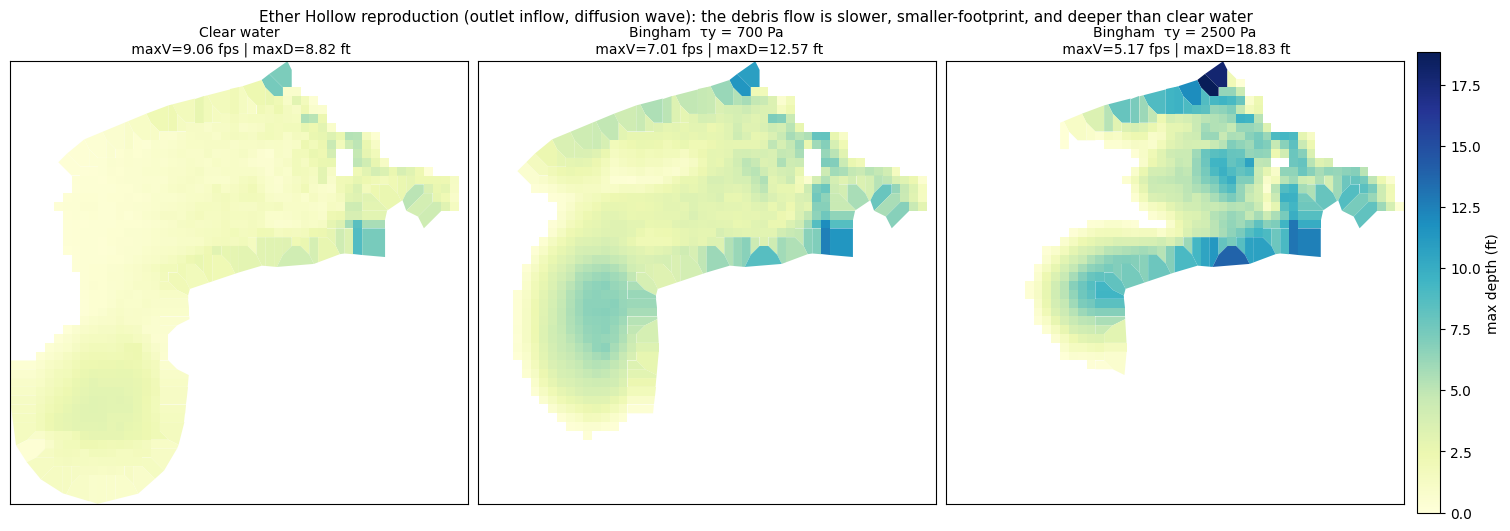

In [6]:
# --- results table + max-depth comparison figure --------------------------------
# The table uses HEC-RAS's own wetted-cell counts (from the run status above). The
# figure colours cells by max depth and draws the wetted extent at a fixed > 0.2 ft
# display cut, so its cell count is slightly lower than HEC-RAS's internal count.
import h5py, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

order = ["clear", "bingham_ty700", "bingham_ty2500"]
labels = {"clear": "Clear water", "bingham_ty700": "Bingham  \u03c4y = 700 Pa",
          "bingham_ty2500": "Bingham  \u03c4y = 2500 Pa"}
table = pd.DataFrame([{
    "variant": labels[k],
    "inflow (cfs)": allres[k]["inflow_peak_cfs"], "max V (fps)": allres[k]["max_vel_fps"],
    "max D (ft)": allres[k]["max_depth_ft"], "mean D (ft)": allres[k]["mean_depth_ft"],
    "wet cells": allres[k]["wet_cells"], "inflow vol (m3)": allres[k]["inflow_vol_m3"],
} for k in order]).set_index("variant")
print(table.to_string())
print(f"\nbulking: {allres['bingham_ty700']['inflow_vol_m3']/allres['clear']['inflow_vol_m3']:.2f}x"
      f"  (1/(1-Cv) = {1/(1-cfg.cv):.2f})")

base = "Geometry/2D Flow Areas/DebrisFlowArea"
sumb = "Results/Unsteady/Output/Output Blocks/Base Output/Summary Output/2D Flow Areas/DebrisFlowArea"
with h5py.File(WORKDIR / "EtherHollow.g01.hdf") as f:
    fpc = f[f"{base}/FacePoints Coordinate"][:]
    cfp = f[f"{base}/Cells FacePoint Indexes"][:]
    cmin = f[f"{base}/Cells Minimum Elevation"][:]
ncell = len(cmin)
polys = [fpc[[i for i in cfp[c] if i >= 0]] for c in range(ncell)]
depths = []
for k in order:
    with h5py.File(WORKDIR / f"result_{k}.p01.hdf") as f:
        ws = f[f"{sumb}/Maximum Water Surface"][0]
    depths.append(np.clip(np.nan_to_num(ws[:ncell] - cmin, nan=0), 0, None))
dmax = max(float(d.max()) for d in depths)
allwet = np.concatenate([np.where(d > 0.2)[0] for d in depths])
xy = np.concatenate([polys[c] for c in allwet])
xlim, ylim = (xy[:, 0].min(), xy[:, 0].max()), (xy[:, 1].min(), xy[:, 1].max())
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
for ax, k, d in zip(axes, order, depths):
    wet = np.where(d > 0.2)[0]
    pc = PolyCollection([polys[c] for c in wet], array=d[wet], cmap="YlGnBu",
                        clim=(0, dmax), edgecolors="none")
    ax.add_collection(pc); ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{labels[k]}\n maxV={allres[k]['max_vel_fps']} fps | "
                 f"maxD={allres[k]['max_depth_ft']} ft", fontsize=10)
fig.colorbar(pc, ax=axes, fraction=0.03, pad=0.01).set_label("max depth (ft)")
fig.suptitle("Ether Hollow reproduction (outlet inflow, diffusion wave): the debris flow "
             "is slower, smaller-footprint, and deeper than clear water", fontsize=11)
plt.show()


Results (same mesh, clear-water hydrograph bulked internally by HEC-RAS; outlet inflow,
Diffusion Wave, 6 h sim):

| variant | inflow peak (cfs) | max V (fps) | max D (ft) | mean D (ft) | runout (wet cells) |
|---|---|---|---|---|---|
| Clear water | 328 | 9.1 | 8.8 | 1.5 | 925 |
| Bingham τy = 700 Pa | 1094 | 7.0 | 12.6 | 3.3 | 834 |
| Bingham τy = 2500 Pa | 1094 | 5.2 | 18.8 | 4.5 | 542 |

Correctly bulked (3.33× at Cv = 0.70 — inflow volume 13,425 → 44,749 m³), the Bingham debris
flows are slower (peak V 9.1 → 7.0 → 5.2 fps), have a smaller footprint (wet cells
925 → 834 → 542), and are deeper (max D 8.8 → 12.6 → 18.8 ft) than the clear-water baseline:
the yield stress makes the flow *hold together* and mound rather than spread. Higher yield
stress → slower, deeper, less spread.

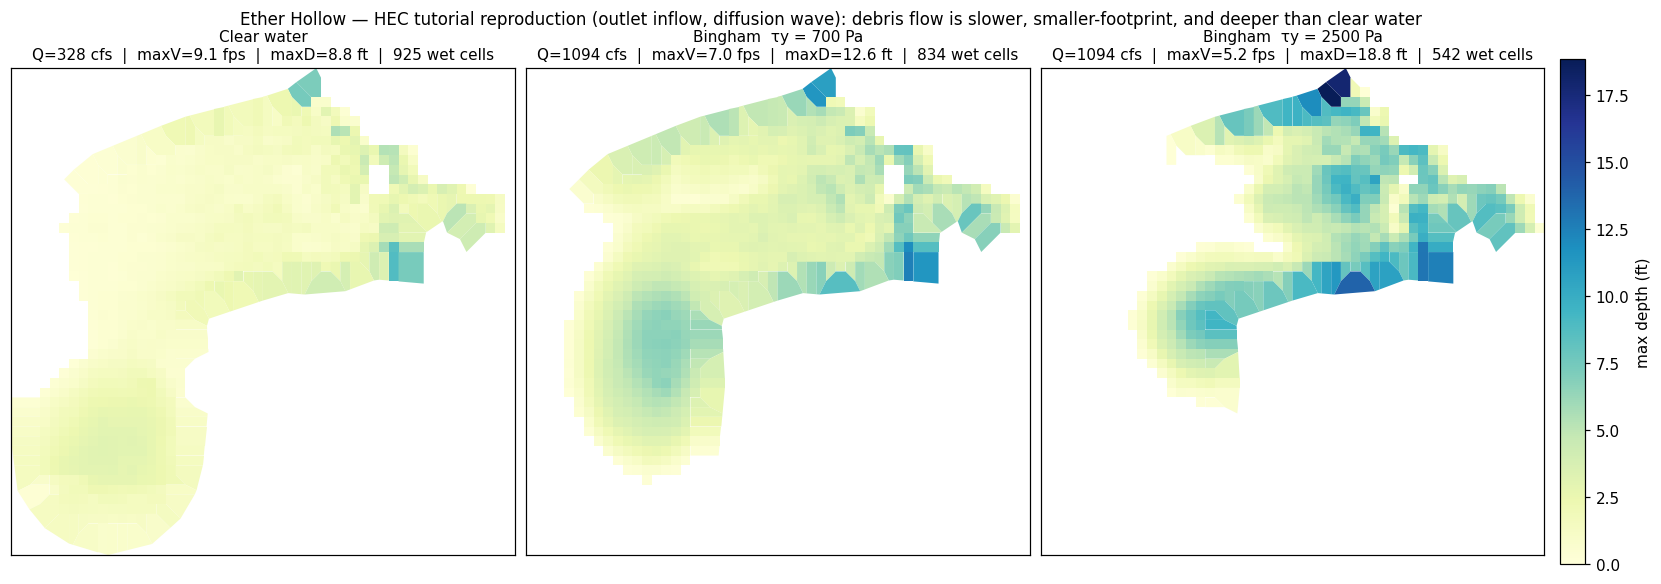

*Max-depth over the fan/runout reach. Left→right: clear water, Bingham τy = 700 Pa, τy = 2500 Pa (same colour scale). Higher yield stress deepens the flow and shrinks the footprint.*

## Interactive map (zoomable)

A `folium`/Leaflet map of the max-depth result (Bingham τy = 700 Pa) on the reproduction mesh, on aerial imagery. Unlike the static figures this is self-contained HTML — it survives `nbconvert` → MkDocs, so it renders live and zoomable in the docs (no kernel).

In [7]:
import h5py, numpy as np, geopandas as gpd, folium
import branca.colormap as cm
from shapely.geometry import Polygon, LineString
from pyproj import CRS

feet = CRS.from_wkt(open(str(WORKDIR / (cfg.project_name + ".projection.prj"))).read())
base = "Geometry/2D Flow Areas/DebrisFlowArea"
sumb = ("Results/Unsteady/Output/Output Blocks/Base Output/Summary Output/"
        "2D Flow Areas/DebrisFlowArea")
with h5py.File(str(WORKDIR / "result_bingham_ty700.p01.hdf")) as f:
    cmin = f[f"{base}/Cells Minimum Elevation"][:]
    fpc  = f[f"{base}/FacePoints Coordinate"][:]
    cfp  = f[f"{base}/Cells FacePoint Indexes"][:]
    ws   = f[f"{sumb}/Maximum Water Surface"][0]      # row 0 = value
depth = np.clip(np.nan_to_num(ws[:len(cmin)] - cmin, nan=0), 0, None)
wet = np.where(depth > 0.2)[0]
cells = gpd.GeoDataFrame(
    {"depth_ft": np.round(depth[wet], 1)},
    geometry=[Polygon(fpc[[i for i in cfp[c] if i >= 0]]) for c in wet],
    crs=feet).to_crs(4326)                            # Leaflet wants lat/lon

c = cells.union_all().centroid
m = folium.Map(location=[c.y, c.x], zoom_start=15, tiles=None)
folium.TileLayer("Esri.WorldImagery", name="Imagery").add_to(m)
folium.TileLayer("OpenStreetMap", name="Street").add_to(m)
cmap = cm.linear.YlOrRd_09.scale(0, cells.depth_ft.max()); cmap.caption = "max depth (ft)"
folium.GeoJson(cells, name="Max depth + mesh cells",
    tooltip=folium.GeoJsonTooltip(["depth_ft"]),
    style_function=lambda x: {"fillColor": cmap(x["properties"]["depth_ft"]),
                              "color": "#333", "weight": 0.3, "fillOpacity": 0.8}).add_to(m)
cmap.add_to(m); folium.LayerControl(collapsed=False).add_to(m)
# folium embeds the zoomable Leaflet map as a self-contained <iframe srcdoc>, which renders on
# the docs site (rascommander.info). GitHub and *untrusted* Jupyter strip embedded iframes from
# outputs for security and fall back to folium's terse "Trust Notebook" placeholder, so wrap the
# map with a clearer message that links to the live, working map.
import html as _html
from IPython.display import HTML

LIVE_MAP_URL = ("https://rascommander.info/ras/notebooks/"
                "319_post_fire_debris_flow_nonnewtonian/#6c-interactive-map-zoomable")
_fallback = (
    '<div style="padding:8px 10px;border:1px solid #d0d7de;border-radius:6px;'
    'background:#f6f8fa;color:#57606a;font:14px system-ui,-apple-system,sans-serif">'
    '\U0001F5FA\uFE0F <b>Interactive map not shown by this viewer.</b> GitHub and untrusted '
    'Jupyter strip embedded map iframes for security. '
    f'<a href="{LIVE_MAP_URL}" target="_blank" rel="noopener">Open the live zoomable map on '
    'rascommander.info \u2192</a><br>In Jupyter, run <i>File \u2192 Trust Notebook</i> to '
    'render it inline.</div>'
)
# self-contained map iframe (does not depend on folium's trust-gated _repr_html_)
_iframe = (f'<iframe srcdoc="{_html.escape(m.get_root().render(), quote=True)}" '
           'style="position:absolute;inset:0;width:100%;height:100%;border:none">'
           '</iframe>')
HTML(f'<div style="position:relative;width:100%;height:520px">{_fallback}{_iframe}</div>')


---
## Beyond the tutorial — extensions

From here we extend the tutorial: the Full-Momentum (SWE-ELM) solver, TauDEM channel
breaklines that refine the mesh along the thalweg, time-synchronized depth×velocity hazard and
arrival-time mapping, a multi-parameter sensitivity band (Cv, viscosity, yield stress,
Manning's n), and a volume-matched scenario bracket.

## 5. Hazard maps — intensity and arrival time

Debris-flow intensity is the depth×velocity product, evaluated *time-synchronized*
(max over time of `d(t)·v(t)` per cell, not `max(d)·max(v)`), and binned into hazard
classes (High ≥ 3.3 ft or 10.8 ft²/s; Med ≥ 1.6 ft or 5.4 ft²/s). Arrival time is the
first time a cell wets (depth > 0.5 ft). Both come from the 121-step 2D time series in the
plan HDF.

With the corrected bulking, the debris flows are deep, fast, and overwhelmingly
high-intensity: ~28–30 ac of high-hazard area each, versus the clear-water baseline's
graded low→high zonation. The intensity (depth×velocity) peaks are destructive
(214–304 ft²/s).

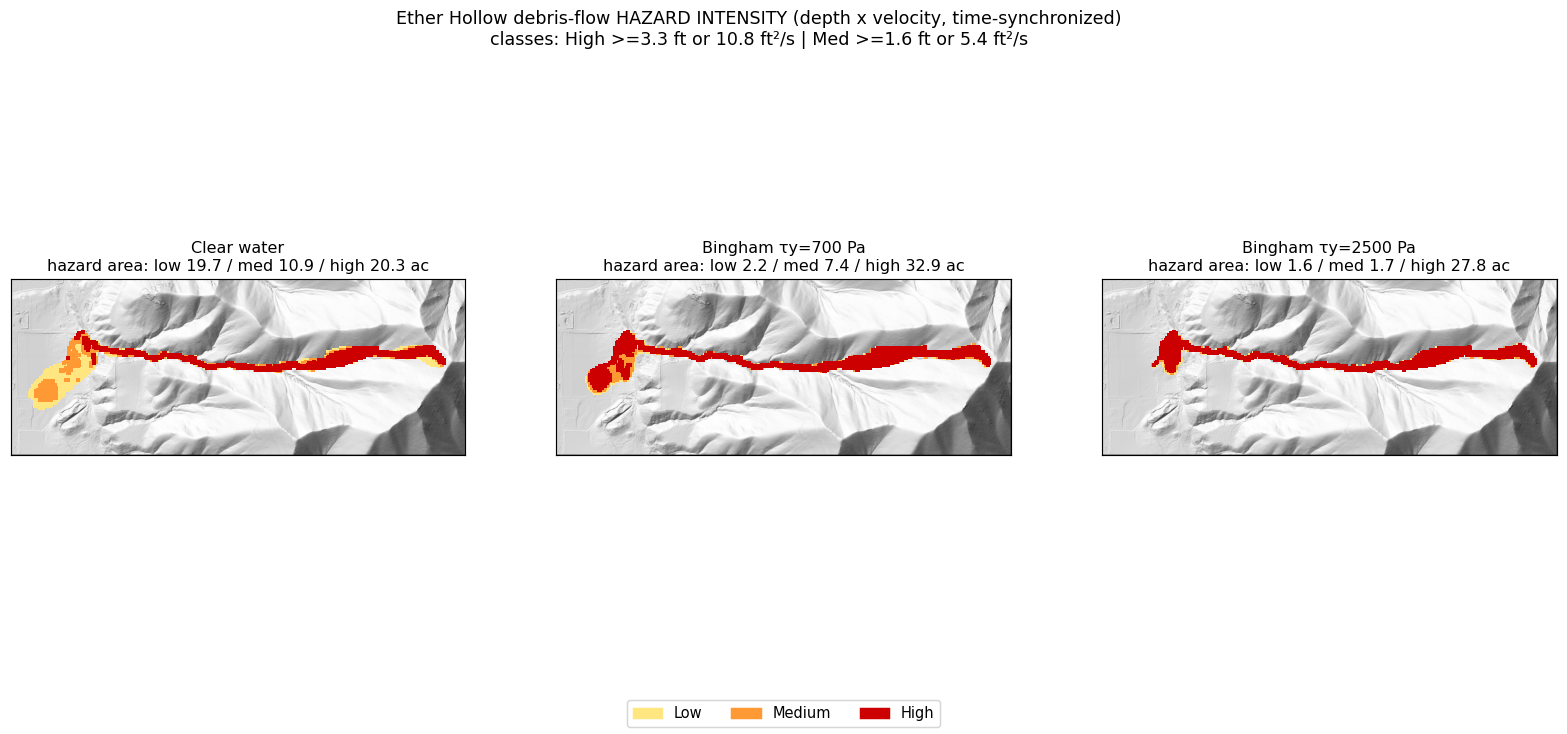

*Depth×velocity hazard intensity (corrected bulking). Bulked debris flows are almost wholly high-hazard.*

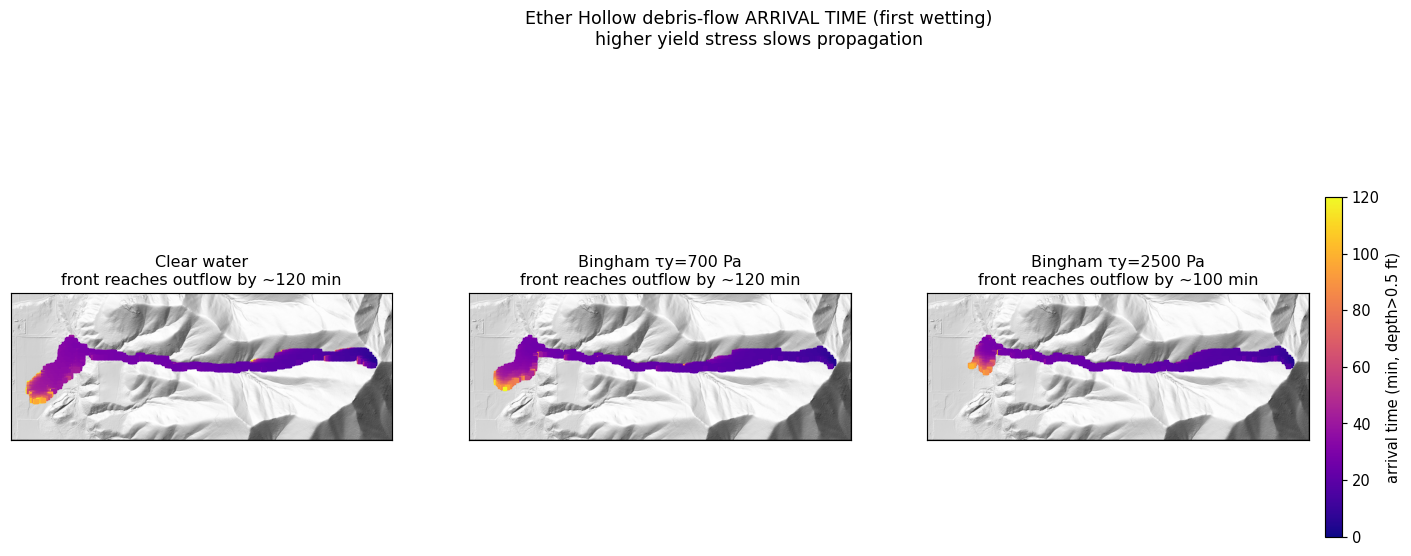

*First-wetting arrival time.*

| variant | low (ac) | med (ac) | high (ac) | total (ac) | peak intensity (ft²/s) |
|---|---|---|---|---|---|
| Clear water | 19.7 | 10.9 | 20.3 | 50.9 | 165 |
| Bingham τy = 700 | 2.2 | 7.4 | 32.9 | 42.4 | 254 |
| Bingham τy = 2500 | 1.6 | 1.7 | 27.8 | 31.0 | 240 |

## 6. Convergence and parameter sensitivity

Numerical convergence. With the Full Momentum solver the run is well-converged in
time — 0.5, 1, and 2 s all give the same peaks (max V ≈ 17.3 fps, max D ≈ 19.1 ft). The
SWE-ELM scheme is more stable here than Diffusion Wave (which went unstable at 2 s). A 1 s
interval is used as a comfortable margin.

Parameter sensitivity (reference: τy = 700 Pa, Cv = 0.70, μ = 100 Pa·s, 1 h, 1 s; one
parameter varied per panel):

- Concentration / bulking (Cv) is a leading control — 0.40 → 0.70 raises the bulked
  inflow 547 → 1094 cfs and max velocity 12.8 → 17.3 fps, expanding runout.
- Viscosity matters — μ 10 → 1000 Pa·s drops max velocity 19.0 → 10.7 fps.
- Yield stress controls depth and extent (τy 700 → 2500: max depth 19.1 → 23.2 ft,
  runout 1539 → 1131 cells) more than velocity.

This is a genuine multi-parameter sensitivity; Cv and viscosity are at least as
influential as yield stress, so a defensible study must vary all three (plus mesh and
roughness — see limitations).

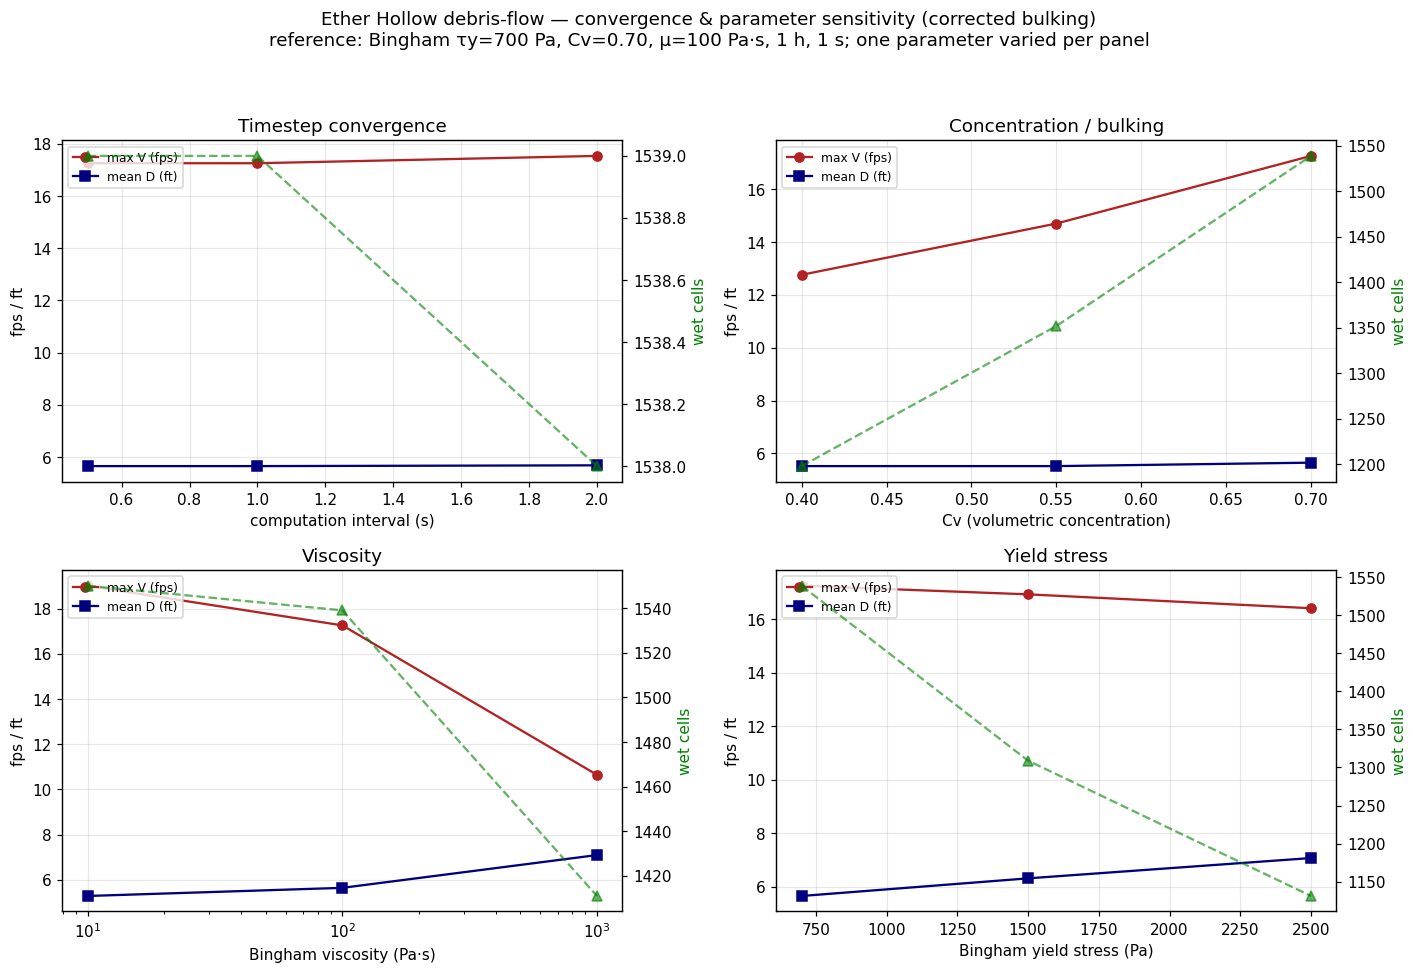

*Convergence (timestep) + sensitivity to Cv, viscosity, and yield stress (corrected bulking).*

### Mesh convergence and roughness (Full Momentum)

Further studies (Bingham τy = 700 Pa, Cv = 0.70, bulked, SWE-ELM):

- Mesh convergence (timestep scaled to hold the Courant number ~constant — 16.5 ft @
  0.25 s, 33 ft @ 1 s, 66 ft @ 2 s): peak velocity is converged (≈15.5–18.4 fps across
  resolutions). Max depth and runout *extent* are moderately mesh-sensitive — a coarser mesh
  over-predicts extent (≈32 / 38 / 52 ac at 16.5 / 33 / 66 ft). 33 ft is a reasonable
  compromise; report extent with a ~±25 % mesh band. (Mesh and timestep must refine together:
  a *fixed* 1 s step at 16.5 ft is Courant-unstable.)
- Manning's n (re-bulked): affects velocity ~30 % (n 0.06 → 0.10) but leaves depth and
  runout extent essentially unchanged — roughness is a second-order control for the debris flow.

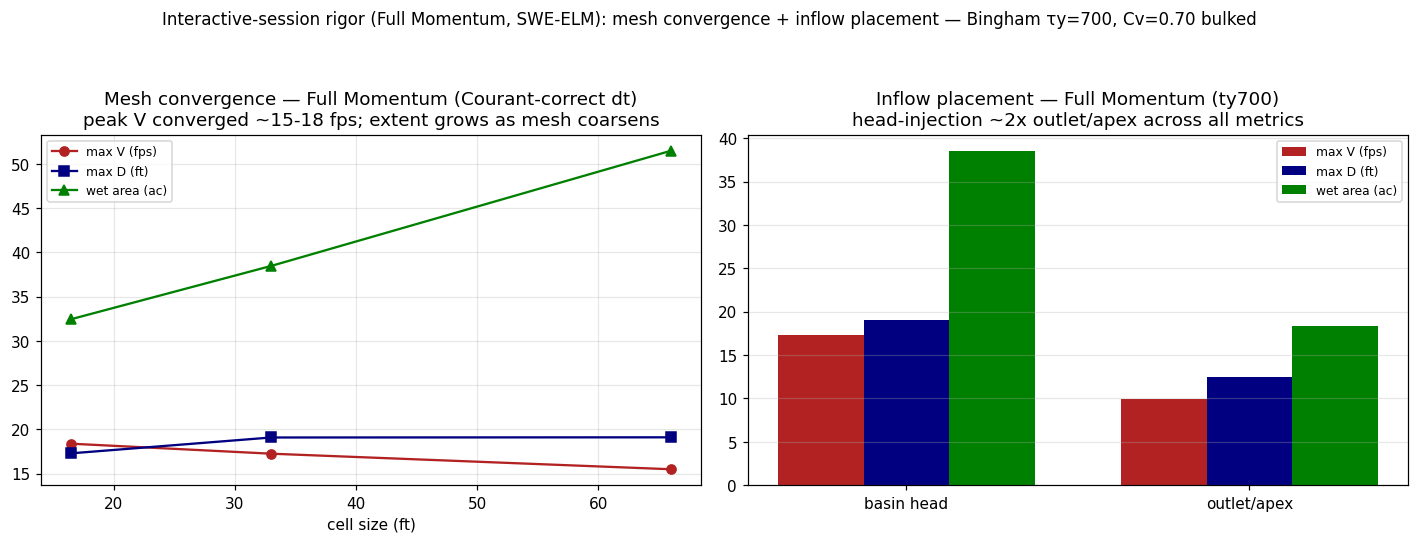

*Mesh convergence (Courant-correct), Full Momentum.*

## 6b. Channel breaklines — refining the mesh along the thalweg

The mesh studies above flagged a resolution artifact: a uniform 33 ft cell averaged
across a narrow, deep channel piles water artificially, over-predicting depth on the thalweg.
The fix is to align cell faces to the channel centerline with breaklines.

Delineation (TauDEM). `delineate_channels.py` runs the TauDEM stream sequence
(PitRemove → D8FlowDir → AreaD8 → Threshold → StreamNet) on the feet terrain, clips the
network to the 2D domain, then walks the network graph to extract continuous main-stem
centerline(s) (longest flow path first) and simplifies them (Douglas–Peucker, 10 ft).
Extracting the longest end-to-end *paths* — not the longest merged *fragments* — keeps the
thalweg continuous across confluences; picking fragments (`linemerge` splits the trunk at
every junction) silently drops mid-trunk reaches and leaves gaps in the centerline.

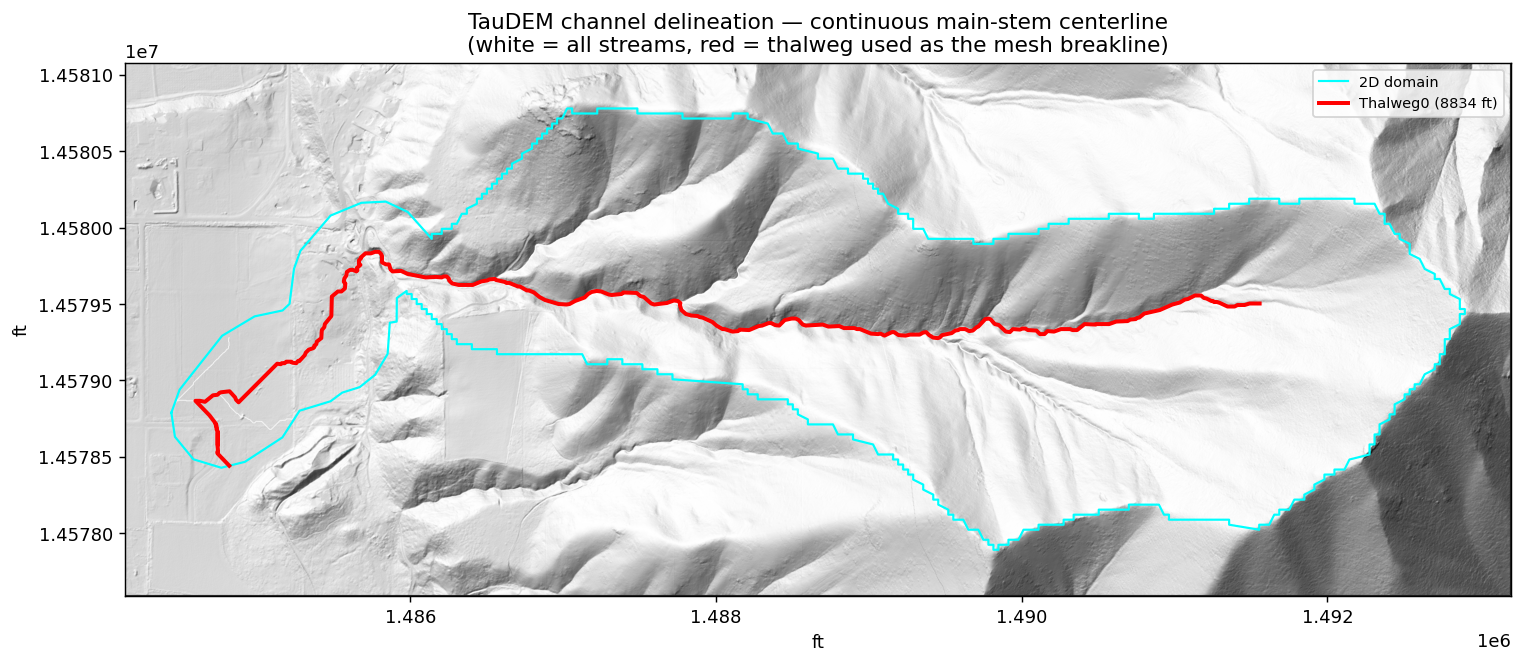

*TauDEM channel delineation (flow-accumulation threshold 0.04 km²): white = all streams, colored = the continuous main-stem centerline(s) used as breaklines, cyan = 2D domain.* <br>*(Figure predates the centerline-continuity fix — regenerate after re-running the delineation.)*

Authoring + enforcement. The build phase authors the centerlines via
`GeomStorage.set_breaklines` with near = far cell spacing (a uniform fine corridor, no
coarsening) and `GeomMesh.set_breakline_spacing(near_repeats, protection_radius=1)` — sizing
`near_repeats` to span the channel width for a constant-width refined band.
`GeomMesh.generate` then enforces the breaklines (the .NET `EnforceBreaklines` regen) and
repairs bad faces via its auto-fix loop; `HdfBndry.get_breaklines` confirms enforcement.

A ~700 ft reach of the main thalweg (red), showing the mesh cell outlines (no fill) over the terrain hillshade. Two figures, same window and scale:

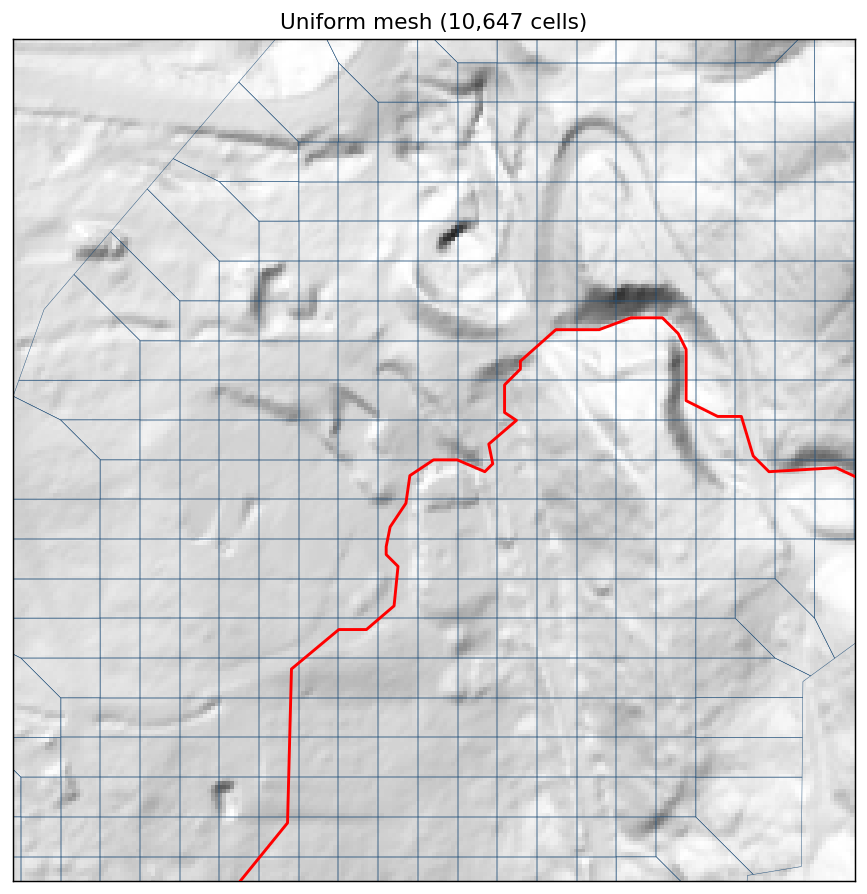

*Uniform mesh (33 ft cells, 10,647 total): coarse cells straddle the narrow, deep thalweg (red) and average it — the source of the spurious over-deepening.*

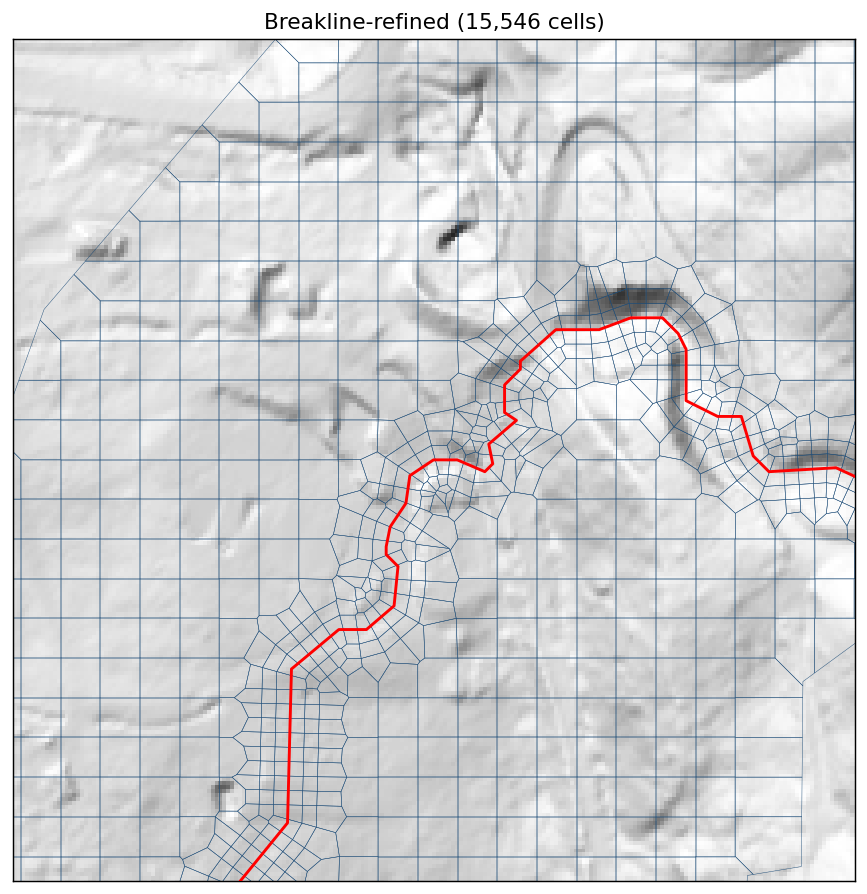

*Breakline-refined mesh (15,546 total): a uniform fine corridor (near = far = 12 ft, near_repeats = 2, protection_radius = 1) follows the continuous channel centerline — two refined rows each side resolve the thalweg cross-section. The perimeter and off-channel cells stay at the 33 ft base spacing.*

Effect (τy = 700 Pa, Full Momentum). Each mesh runs at its Courant-stable timestep — the
33 ft mesh at 1 s, the 12 ft mesh at 0.5 s. (At 1 s the refined mesh runs Courant ≈ 2 and
inflates peak velocity to ~25 ft/s; 0.5 s and 0.2 s agree to ~0.1 ft/s, so 0.5 s is
converged.)

| metric | uniform 33 ft @ 1 s | breakline-refined 12 ft @ 0.5 s |
|---|---|---|
| max velocity (fps) | 17.3 | 20.0 |
| max depth (ft) | 19.1 | 13.4 |
| mean depth (ft) | 5.6 | 4.3 |
| cells | 10,647 | 15,546 |

The channel-aligned refinement (near = far = 12 ft, near_repeats = 2, protection_radius = 1)
drops the spurious max depth 19.1 → 13.4 ft as the resolved thalweg — not a single coarse
cell — carries the flow; peak velocity rises modestly (17.3 → 20.0 ft/s) as the continuous
channel is resolved. Mesh and timestep must refine together: the finer cells need the smaller
computation interval to stay Courant-stable, or the under-resolved timestep inflates velocity.
TauDEM 5.x + MS-MPI are required for the delineation (CPU-only; can run off the HEC-RAS host).

## 6d. Hazard on the refined mesh

Re-running the hazard products on the breakline-refined mesh (15,546 cells, converged at a
0.5 s interval) shows the refinement's effect on the hazard footprint, not just the peak
depth. Resolving the thalweg concentrates the debris flow into a tight high-hazard channel
corridor and removes the over-predicted high-hazard *spread* of the coarse mesh:

| τy = 700 Pa | low (ac) | med (ac) | high (ac) | total (ac) |
|---|---|---|---|---|
| uniform 33 ft | 2.2 | 7.4 | 32.9 | 42.4 |
| breakline-refined 12 ft | 2.7 | 8.6 | 24.3 | 35.6 |

The high-hazard area drops 32.9 → 24.3 ac as the spurious over-deepened cells are
resolved — the flow tracks the channel instead of smearing across coarse cells. (Compare the
uniform-mesh maps in §5.)

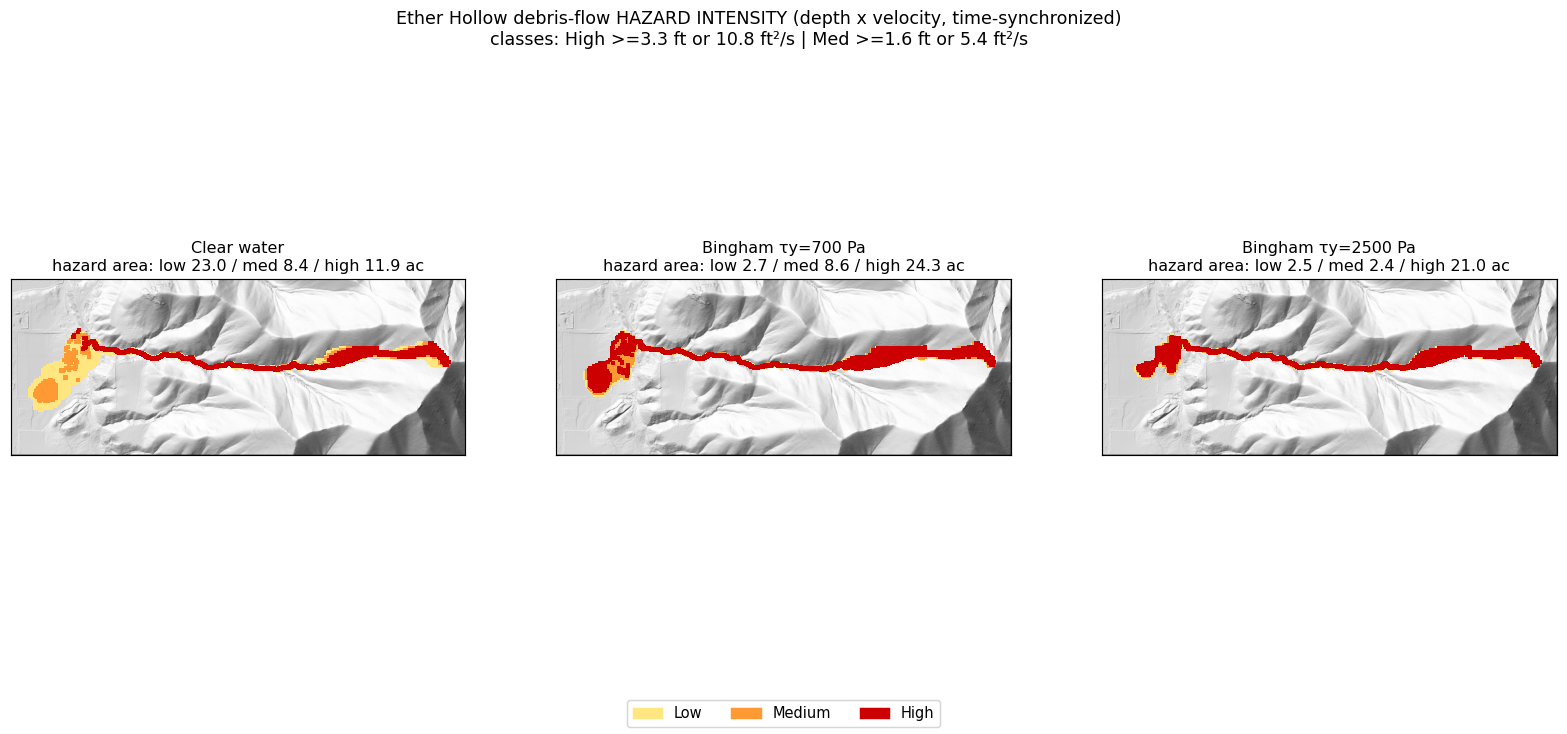

*Depth×velocity hazard intensity on the breakline-refined mesh. The high-hazard class hugs the resolved thalweg rather than the coarse-mesh smear of §5.*

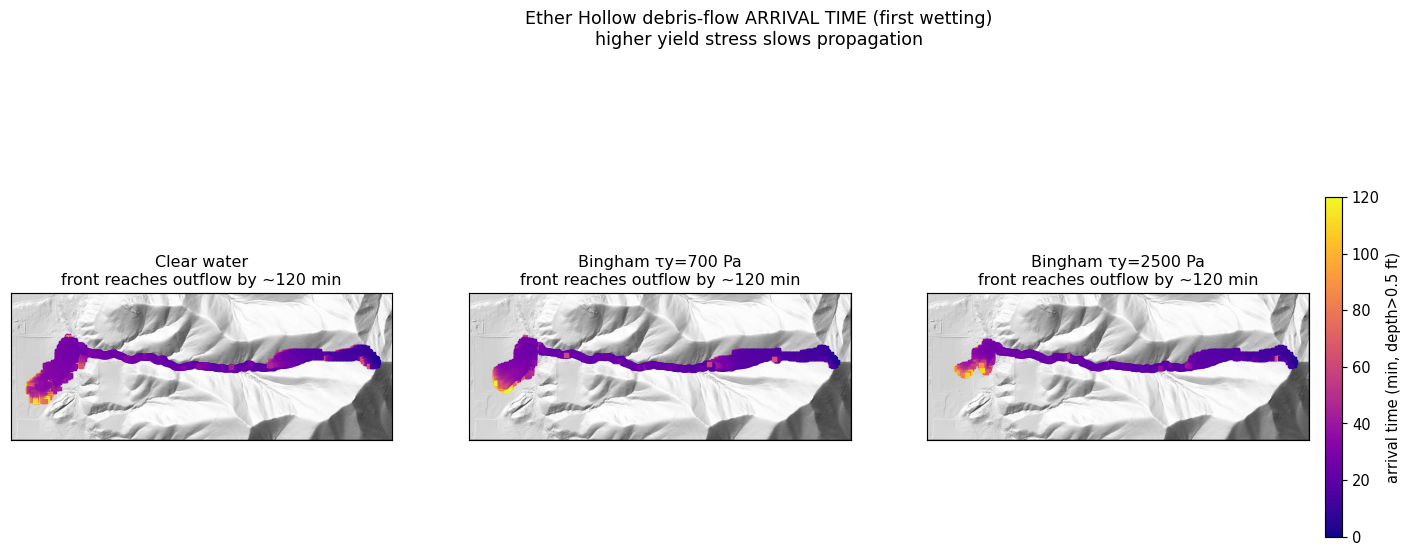

*First-wetting arrival time on the refined mesh; the front reaches the outflow by ~114–120 min, as on the uniform mesh.*

## 7. Mass balance, scenario bracket, and limitations

Mass balance. The clear-water hydrograph integrates to ~13,400 m³ of water; at Cv = 0.70 that implies ~31,000 m³ of debris — about 3.5× the USGS empirically predicted debris-flow volume (~9,000 m³), and the HMS peak (328 cfs) exceeds the BAER-reported mouth range (~82–221 cfs). The default run is therefore an upper-bound scenario.

Scenario bracket. `--inflow-scale` produces a volume-matched companion run: scaling the inflow to ~0.29 brings the bulked debris volume to ≈ the USGS 9,019 m³ (clear peak ~95 cfs, within the BAER range), which roughly halves peak velocity (17.7 → 10.9 fps) and shrinks runout ~35%. Report the upper-bound and volume-matched runs as a bracket.

Hazard intensity uses a cell-centered velocity — HEC-RAS stores only face-normal velocities, so each cell's vector is reconstructed by least-squares (`u·n_f = v_f`). The simpler max-face estimator biases velocity ~10% high, though the high-hazard *area* is unchanged here (the debris-flow high class is depth-dominated).

Still open (this is a methods demonstration): field validation against observed Ether Hollow deposits / a benchmark case — which needs post-event imagery or a deposit survey not in the public USGS DF-prediction dataset. The volume + BAER-peak match above is calibration to the available benchmarks, not deposit-extent validation.

## Summary

Starting from public USGS/3DEP data and a blank template, `ras-commander` recreated the HEC
Expedited Debris Flow Tutorial end to end: a greenfield mesh + terrain-in-mesh, a clear-water
baseline, and Bingham non-Newtonian variants with internal bulking, inflow at the fan apex.

Recreating the tutorial — key points
- The from-scratch greenfield 2D path is seed-points → preprocess → terrain-in-mesh; perimeter
  validity and full terrain coverage are essential (a mesh over nodata is rejected by
  HEC-RAS as "terrain does not cover the 2D Flow Area").
- With outlet / fan-apex inflow, the Bingham debris flows are slower (9.1 → 7.0 → 5.2 fps),
  smaller-footprint (925 → 834 → 542 wet cells), and deeper (8.8 → 12.6 → 18.8 ft) than
  clear water.
- Verify bulking with a mass balance. Cv is entered in *percent*; a fraction silently
  disables bulking. Correctly bulked (3.33×), the mixture volume is 13,425 → 44,749 m³.

Extending it — the Full-Momentum solver, TauDEM channel breaklines, depth×velocity hazard /
arrival mapping, a multi-parameter sensitivity band, and a volume-matched scenario bracket.